# Import libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions

from scipy import stats
from collections import Counter
from nltk.corpus import stopwords

from eda_utils import preprocess_text, corpus_word_frequency, frequency_df, rare_words_ratio, question_stats, word_overlap_features, distribution_plot

pd.set_option('display.max_colwidth', None)

In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
STOP_WORDS = set(stopwords.words('english'))

# Dara Loading

In [4]:
df = pd.read_csv('quora_question_pairs_train.csv.zip', index_col=0)
df.head()

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0
266232,101283,163744,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0
122738,17811,27517,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?,Why don't many people posting questions on Quora check Google first?,1


# Data Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 323432 entries, 332278 to 402019
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   qid1          323432 non-null  int64 
 1   qid2          323432 non-null  int64 
 2   question1     323431 non-null  object
 3   question2     323430 non-null  object
 4   is_duplicate  323432 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 14.8+ MB


In [6]:
print("Number of rows in the dataset:", df.shape[0])
print("Number of columns in the dataset:", df.shape[1])

Number of rows in the dataset: 323432
Number of columns in the dataset: 5


In [7]:
if df.duplicated().any():
    print("There are duplicate rows in the dataset.")
else:
    print("Duplicate rows are not observed.")

Duplicate rows are not observed.


**Observation:**
- No rows duplication is observed.

In [8]:
print("Number of missing values:", df.isnull().values.sum())

Number of missing values: 3


In [9]:
print("Presence of gaps in columns")
df.isna().sum()

Presence of gaps in columns


qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df[df.isna().any(axis=1)]

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
363362,493340,493341,NaN,My Chinese name is Haichao Yu. What English name is most suitable for me considering the pronounciation of my Chinese name?,0
201841,303951,174364,How can I create an Android app?,NaN,0
105780,174363,174364,How can I develop android app?,NaN,0


**Observation:**
- Since there are no rows with missing question values, they can be deleted, or only these specific questions can be deleted by combining the two blocks of questions into one long table and skipping each question with N-1 others during training.

# Semantic analysis of the entire dataset

## Question length distribution

Distribution of the length of the first question


count    323431.00
mean         59.53
std          29.92
min           1.00
50%          52.00
90%          99.00
99%         150.00
max         623.00
Name: question1, dtype: float64

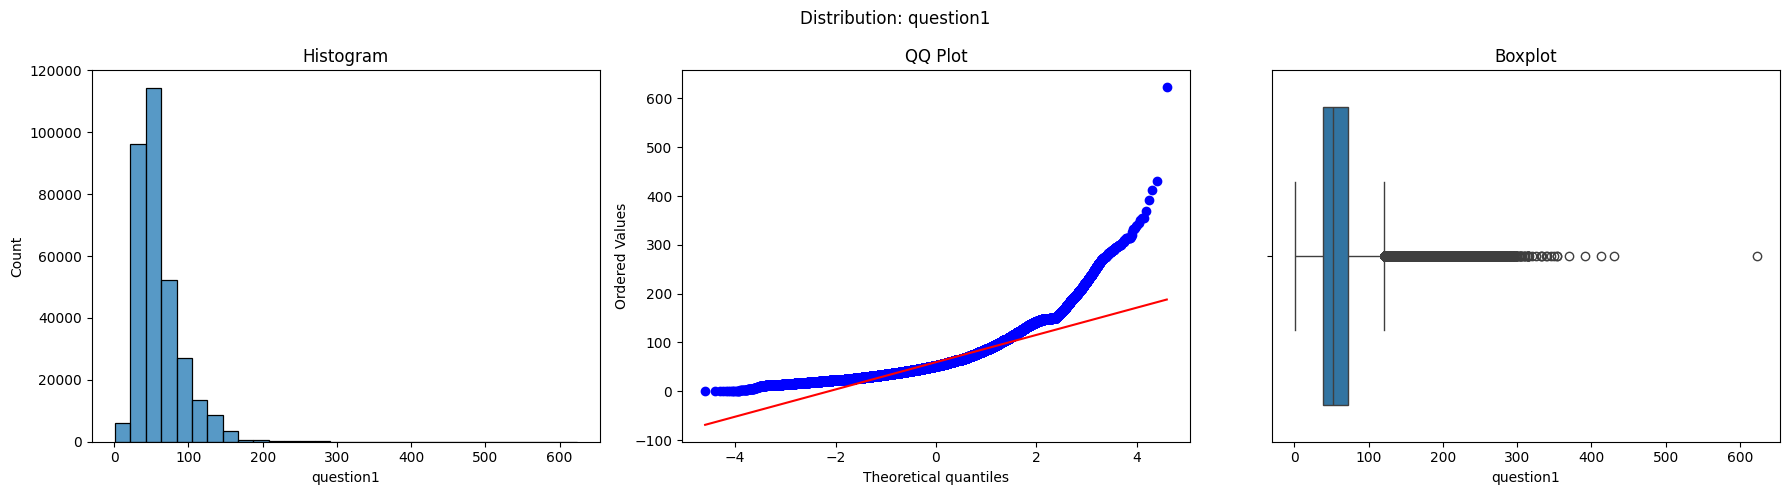

Distribution of the length of the second question


count    323430.00
mean         60.12
std          33.89
min           1.00
50%          51.00
90%         103.00
99%         171.00
max        1169.00
Name: question2, dtype: float64

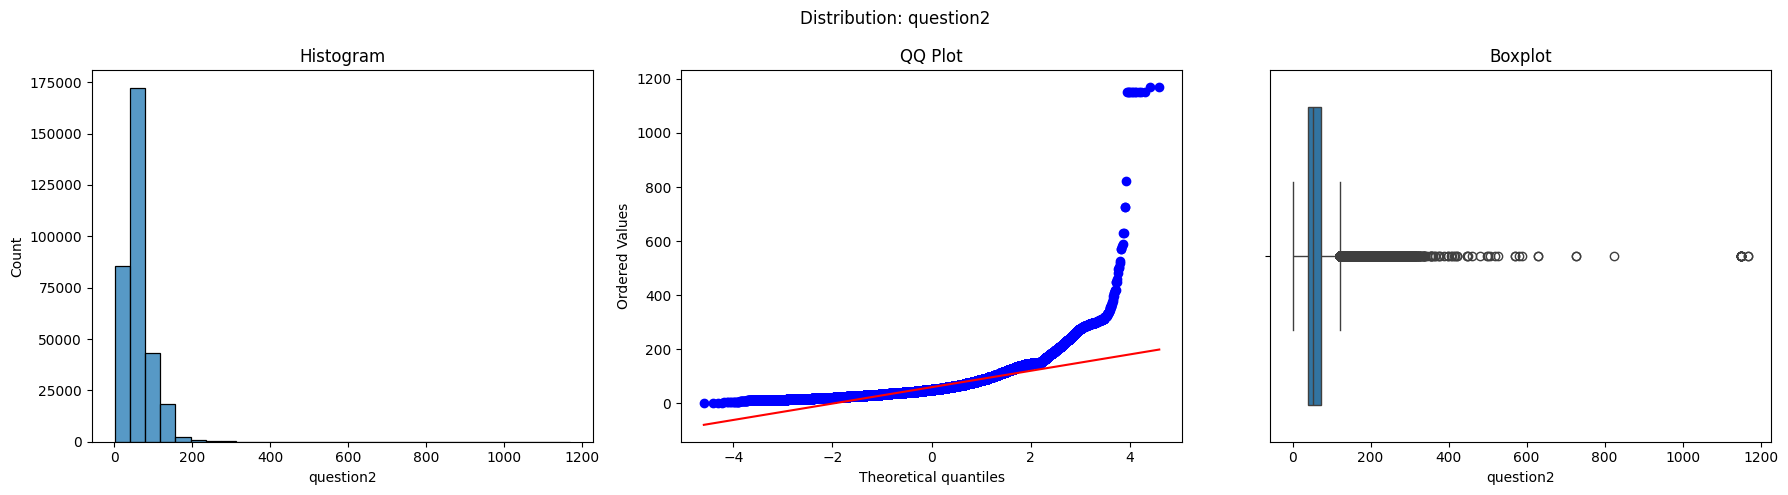

In [11]:
q1_len = df['question1'].str.len()
q2_len = df['question2'].str.len()

print("Distribution of the length of the first question")
display(q1_len.describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(q1_len)

print("Distribution of the length of the second question")
display(q2_len.describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(q2_len)

**Observation**
- We have a right-skewed distribution of question lengths, with 50% of questions being up to 52 characters long, while about 10% of questions are longer than 100 characters.

## Question uniqueness analysis

Number of unique question IDs in the dataset: 449792
Maximum number of occurrences of one unique question: 122
Share of unique questions occurring more than once: 0.191


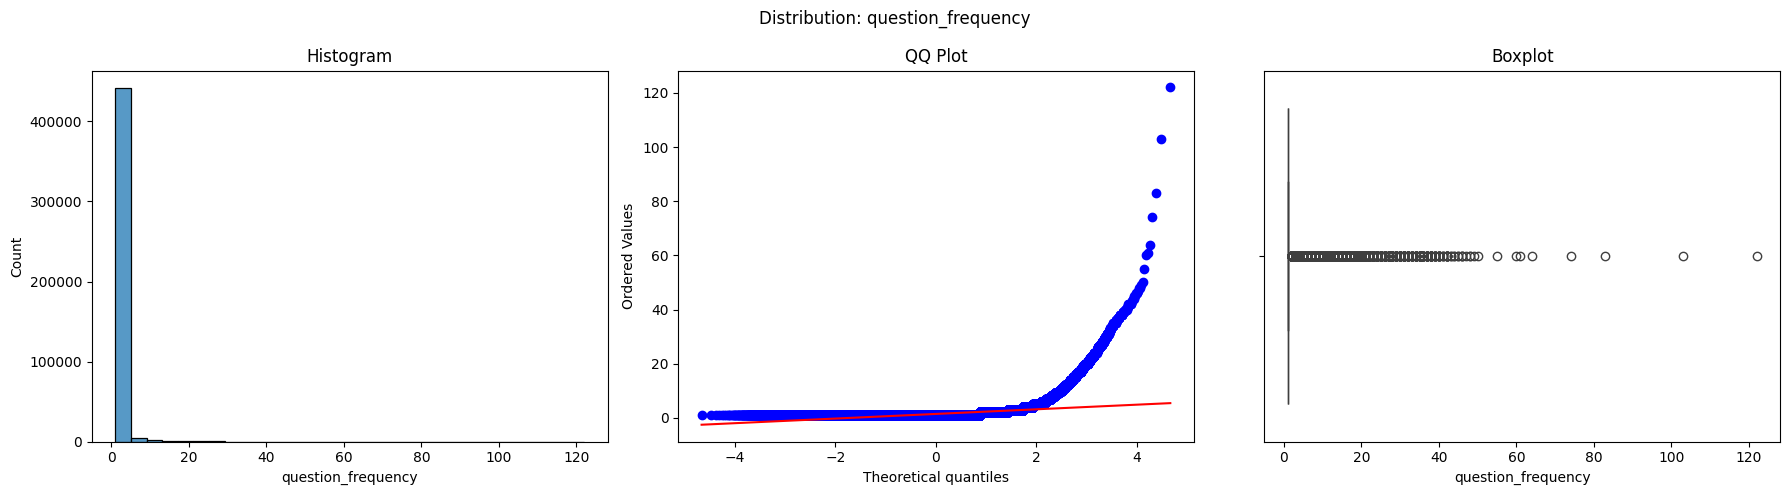

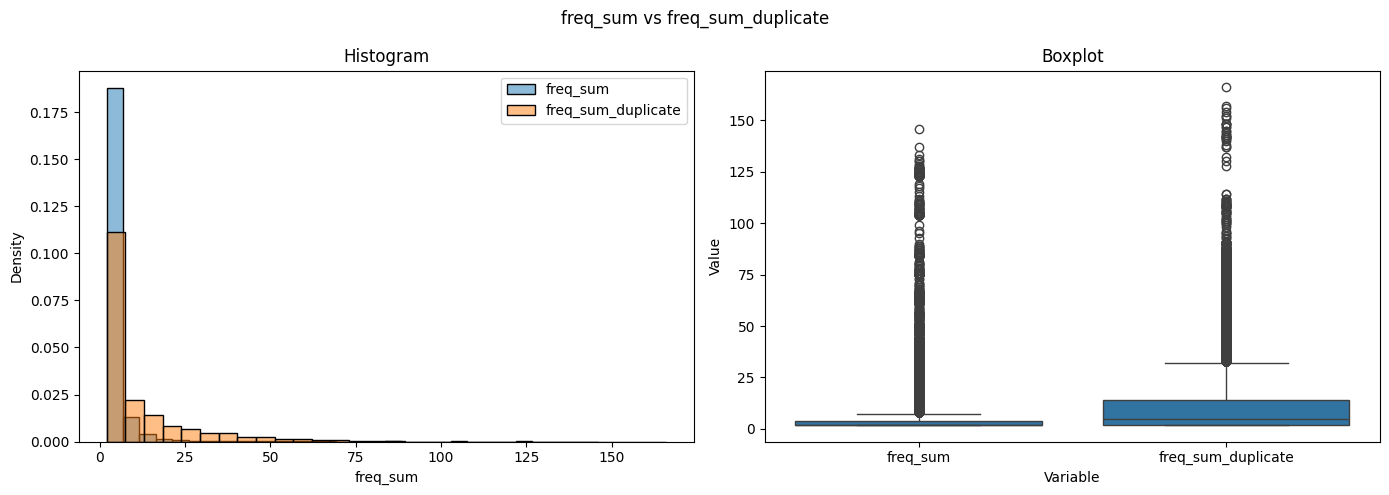

In [12]:
qid_counts = pd.concat([df['qid1'], df['qid2']]).value_counts()

print("Number of unique question IDs in the dataset:", qid_counts.shape[0])
print("Maximum number of occurrences of one unique question:", qid_counts.max())
print("Share of unique questions occurring more than once:", round((qid_counts > 1).mean(), 4))

distribution_plot(qid_counts.rename("question_frequency"))


df_freq = df.copy()
df_freq["qid1_freq"] = df_freq["qid1"].map(qid_counts)
df_freq["qid2_freq"] = df_freq["qid2"].map(qid_counts)
df_freq["freq_sum"] = df_freq["qid1_freq"] + df_freq["qid2_freq"]

distribution_plot(
    df_freq.loc[df_freq['is_duplicate'] == 0, 'freq_sum'],
    df_freq.loc[df_freq['is_duplicate'] == 1, 'freq_sum'].rename('freq_sum_duplicate')
)

**Observation:**
- About 19.1% of questions occur more than once in the dataset.
- The frequency distribution of the same question indicates that, for the most part, non-duplicate questions are less common in the dataset than duplicate questions, which is quite logical. It is important to take this into account when splitting the dataset into training and validation samples, so that questions of the same group remain in one subsample to prevent bias in the quality assessment.

## Check for mirror questions

In [13]:
question1_clean = df['question1'].str.strip().str.lower()
question2_clean = df['question2'].str.strip().str.lower()

is_identical = question1_clean == question2_clean

identical_pairs = df[is_identical]

print("Number of pairs with the same text:", len(identical_pairs))
display(identical_pairs[['qid1', 'qid2', 'question1', 'question2', 'is_duplicate']].head(20))

strange_cases = identical_pairs[identical_pairs['is_duplicate'] == 0]

print("Number of pairs marked as non-duplicate:", len(strange_cases))
display(strange_cases[['qid1', 'qid2', 'question1', 'question2', 'is_duplicate']])

Number of pairs with the same text: 18


,qid1,qid2,question1,question2,is_duplicate
id,,,,,
359339,488974,480151,What is the meaning of this sentence below?,What is the meaning of this sentence below?,0
384501,162198,74460,What is the most beautiful moment in your life?,What is the most beautiful moment in your life?,1
257101,372357,372358,How do small business owners use CRM systems?,How do small business owners use CRM systems?,1
299649,422330,422331,Who is this?,Who is this?,0
233905,344263,125570,What is the best way to print a book of photos taken on an iPhone?,What is the best way to print a book of photos taken on an iPhone?,1
46601,83338,74190,Should I stop masturbating?,Should I stop masturbating?,1
70303,121195,121196,How much computer science does an 8 year old US kid typically know or is taught in school curricula?,How much computer science does an 8 year old US kid typically know or is taught in school curricula?,1
194310,294484,294485,How would you rephrase this sentence?,How would you rephrase this sentence?,0
115053,187684,41938,What are the chances I could be pregnant?,What are the chances I could be pregnant?,0


Number of pairs marked as non-duplicate: 5


,qid1,qid2,question1,question2,is_duplicate
id,,,,,
359339,488974,480151,What is the meaning of this sentence below?,What is the meaning of this sentence below?,0
299649,422330,422331,Who is this?,Who is this?,0
194310,294484,294485,How would you rephrase this sentence?,How would you rephrase this sentence?,0
115053,187684,41938,What are the chances I could be pregnant?,What are the chances I could be pregnant?,0
386629,518854,39099,What does my birth chart say about me?,What does my birth chart say about me?,0


In [14]:
df_mir = df.copy()
df_mir['smaller_qid'] = np.minimum(df_mir['qid1'], df_mir['qid2'])
df_mir['bigger_qid'] = np.maximum(df_mir['qid1'], df_mir['qid2'])

is_mirror = df_mir.duplicated(subset=['smaller_qid', 'bigger_qid'], keep=False)

mirror_pairs = df_mir[is_mirror].sort_values(['smaller_qid', 'bigger_qid'])

print("Number of rows that are included in duplicate pairs (written twice):", len(mirror_pairs))
display(mirror_pairs[['qid1', 'qid2', 'question1', 'question2', 'is_duplicate']].head(20))

label_conflicts = mirror_pairs.groupby(['smaller_qid', 'bigger_qid'])['is_duplicate'].nunique()
print("Couples with conflicting labels:", (label_conflicts > 1).sum())

Number of rows that are included in duplicate pairs (written twice): 0


,qid1,qid2,question1,question2,is_duplicate
id,,,,,


Couples with conflicting labels: 0


**Observation**
- There are 18 pairs with exactly the same questions under different identifiers. At the same time, 5 of them are mistakenly marked as non-duplicates, which should be taken into account in preprocessing, since such cases can affect the formation of patterns in the model.
- There are no duplicate rows containing duplicate pairs.

## Semantic analysis of the entire data set

### Analysis with stop words

In [15]:
processed_df = df.copy()

processed_df["question1_tokens"] = processed_df["question1"].apply(
    lambda text: preprocess_text(
        text, 
        remove_numbers=True,
        remove_stopwords=False
    )
)

processed_df["question2_tokens"] = processed_df["question2"].apply(
    lambda text: preprocess_text(
        text, 
        remove_numbers=True,
        remove_stopwords=False
    )
)

processed_df.head(3)

,qid1,qid2,question1,question2,is_duplicate,question1_tokens,question2_tokens
id,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0,"[the, iliad, and, the, odyssey, in, the, greek, culture]","[how, do, i, prove, that, the, pairs, of, three, independent, variables, is, also, independent]"
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0,"[what, is, practical, management, and, what, is, strategic, management]","[what, are, the, practical, aspects, of, strategic, management]"
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0,"[how, useful, is, makeuseof, answers]","[is, there, any, q, a, site, that, is, not, yahoo, answers, where, hate, speech, is, allowed]"


In [16]:
word_frequency = corpus_word_frequency(processed_df)

print("Dictionary size:", len(word_frequency))
print("Proportion of rare words occurring 1 time:", round(rare_words_ratio(word_frequency), 4))

freq_df = frequency_df(word_frequency)

print("Most frequently used words")
display(freq_df.head(10))

print("Least frequently used words")
display(freq_df.tail(10))

Dictionary size: 72758
Proportion of rare words occurring 1 time: 0.382
Most frequently used words


,word,frequency,share_percent
0,the,302209,4.2087
1,what,260010,3.6210
2,is,231589,3.2252
3,i,179716,2.5028
4,how,176806,2.4623
5,a,170570,2.3754
6,to,165216,2.3009
7,in,157625,2.1951
8,do,135949,1.8933
9,of,127925,1.7815


Least frequently used words


,word,frequency,share_percent
72748,tripods,1,0.0
72749,heptarchy,1,0.0
72750,biel,1,0.0
72751,cramer,1,0.0
72752,wildau,1,0.0
72753,stuents,1,0.0
72754,boudin,1,0.0
72755,snowboards,1,0.0
72756,humanzee,1,0.0
72757,kolkta,1,0.0


### Analysis without stop words

In [17]:
processed_nosw_df = df.copy()

processed_nosw_df["question1_tokens"] = processed_nosw_df["question1"].apply(
    lambda text: preprocess_text(
        text, 
        remove_numbers=True,
        remove_stopwords=True,
        stop_words=STOP_WORDS
    )
)

processed_nosw_df["question2_tokens"] = processed_nosw_df["question2"].apply(
    lambda text: preprocess_text(
        text, 
        remove_numbers=True,
        remove_stopwords=True,
        stop_words=STOP_WORDS
    )
)

processed_nosw_df.head(3)

,qid1,qid2,question1,question2,is_duplicate,question1_tokens,question2_tokens
id,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0,"[iliad, odyssey, greek, culture]","[prove, pairs, three, independent, variables, also, independent]"
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0,"[practical, management, strategic, management]","[practical, aspects, strategic, management]"
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0,"[useful, makeuseof, answers]","[q, site, yahoo, answers, hate, speech, allowed]"


In [18]:
word_nosw_frequency = corpus_word_frequency(processed_nosw_df)

print("Dictionary size excluding stop words:", len(word_nosw_frequency))
print("Proportion of rare words occurring once, excluding stop words:", round(rare_words_ratio(word_nosw_frequency), 4))

freq_nosw_df = frequency_df(word_nosw_frequency)

print("Most frequently used words excluding stop words")
display(freq_nosw_df.head(10))

print("Least frequently used words excluding stop words")
display(freq_nosw_df.tail(10))

Dictionary size excluding stop words: 72618
Proportion of rare words occurring once, excluding stop words: 0.3827
Most frequently used words excluding stop words


,word,frequency,share_percent
0,best,56499,1.6125
1,get,31646,0.9032
2,india,23713,0.6768
3,people,21188,0.6047
4,like,20499,0.5850
5,good,19999,0.5708
6,would,19354,0.5524
7,one,16079,0.4589
8,make,14605,0.4168
9,quora,14537,0.4149


Least frequently used words excluding stop words


,word,frequency,share_percent
72608,snowboards,1,0.0
72609,humanzee,1,0.0
72610,kolkta,1,0.0
72611,ehrs,1,0.0
72612,emrs,1,0.0
72613,jaruk,1,0.0
72614,sponsorchat,1,0.0
72615,askapatient,1,0.0
72616,wacc,1,0.0
72617,calabases,1,0.0


**Observations:**
- There are typos in the texts, as well as different forms of adjectives, for example, good, best.
- The share of rare words that occur 1 time, both including stop words and no, is approximately 38%.

## Analysis of individual issues

### Analysis with stop words

In [19]:
question_stats_df = question_stats(processed_df)
question_stats_df.head(3)

,qid1,qid2,question1,question2,is_duplicate,question1_tokens,question2_tokens,question1_char_count,question1_word_count,question1_unique_word_count,question1_unique_ratio,question1_avg_word_length,question1_max_word_length,question2_char_count,question2_word_count,question2_unique_word_count,question2_unique_ratio,question2_avg_word_length,question2_max_word_length
id,,,,,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0,"[the, iliad, and, the, odyssey, in, the, greek, culture]","[how, do, i, prove, that, the, pairs, of, three, independent, variables, is, also, independent]",47,9,7,0.777778,4.222222,7,81,14,13,0.928571,4.785714,11
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0,"[what, is, practical, management, and, what, is, strategic, management]","[what, are, the, practical, aspects, of, strategic, management]",62,9,6,0.666667,5.888889,10,55,8,8,1.0,5.875000,10
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0,"[how, useful, is, makeuseof, answers]","[is, there, any, q, a, site, that, is, not, yahoo, answers, where, hate, speech, is, allowed]",32,5,5,1.0,5.400000,9,78,16,14,0.875,3.812500,7


Question length distribution


,question1_char_count,question2_char_count
count,323432.00,323432.00
mean,59.53,60.12
std,29.92,33.89
min,0.00,0.00
50%,52.00,51.00
90%,99.00,103.00
99%,150.00,171.00
max,623.00,1169.00


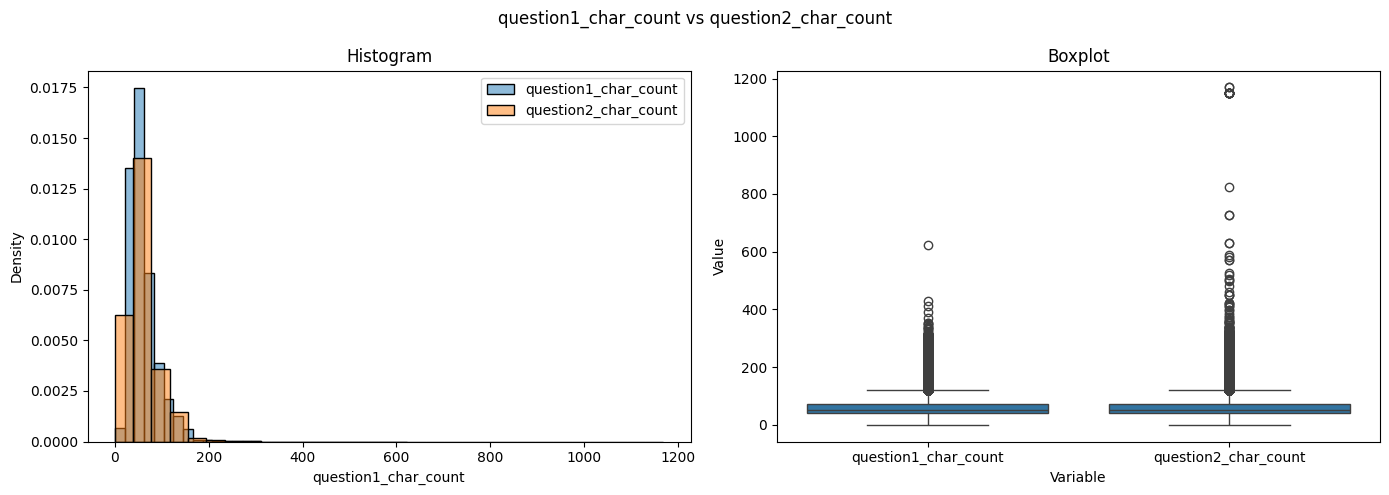

Word count distribution in questions


,question1_word_count,question2_word_count
count,323432.00,323432.00
mean,10.98,11.22
std,5.46,6.36
min,0.00,0.00
50%,10.00,10.00
90%,18.00,19.00
99%,29.00,33.00
max,127.00,245.00


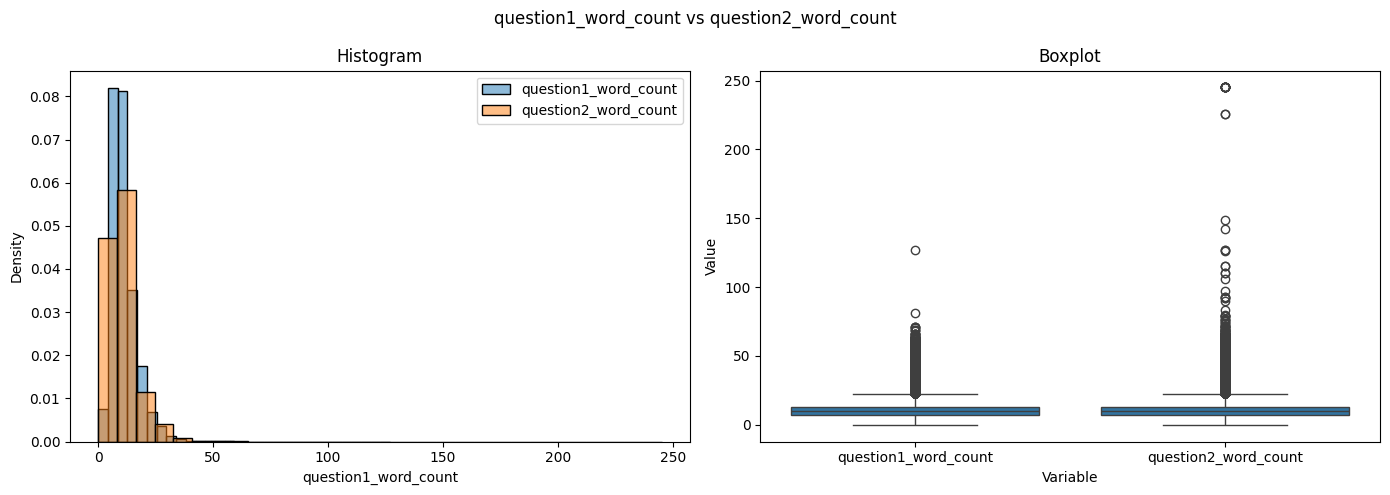

Distribution of the number of unique words in questions


,question1_unique_word_count,question2_unique_word_count
count,323432.00,323432.00
mean,10.41,10.57
std,4.58,5.12
min,0.00,0.00
50%,9.00,9.00
90%,16.00,17.00
99%,25.00,27.00
max,93.00,127.00


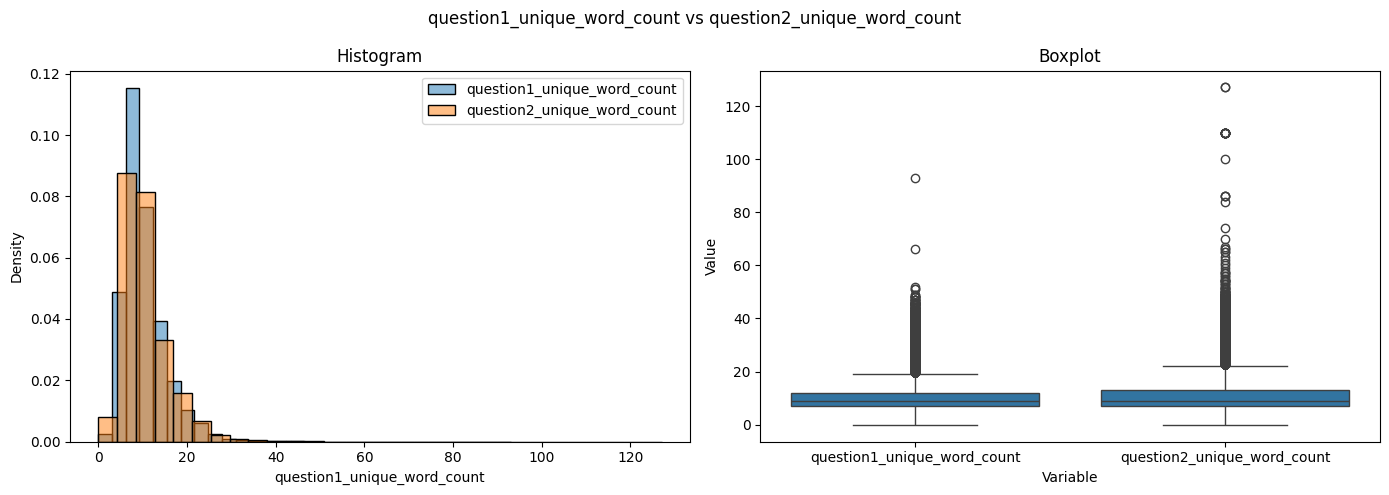

Distribution of average word lengths in questions


,question1_avg_word_length,question2_avg_word_length
count,323432.00,323432.00
mean,4.37,4.32
std,0.77,0.76
min,0.00,0.00
50%,4.31,4.25
90%,5.38,5.29
99%,6.50,6.44
max,11.00,15.67


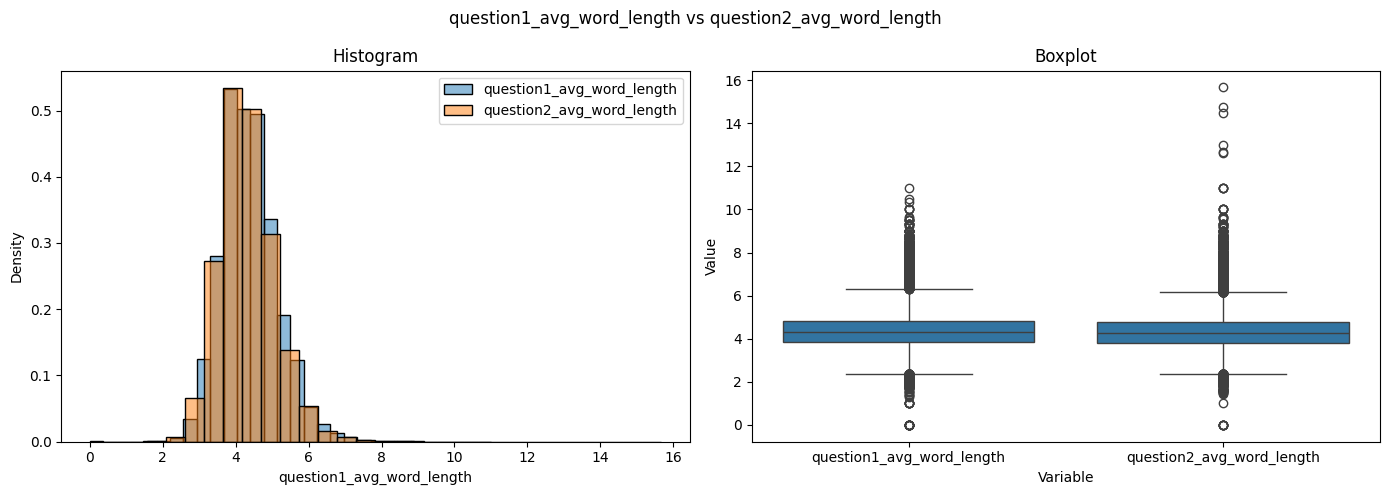

Distribution of maximum word length in questions


,question1_max_word_length,question2_max_word_length
count,323432.00,323432.00
mean,8.67,8.56
std,2.16,2.15
min,0.00,0.00
50%,9.00,8.00
90%,11.00,11.00
99%,14.00,14.00
max,52.00,52.00


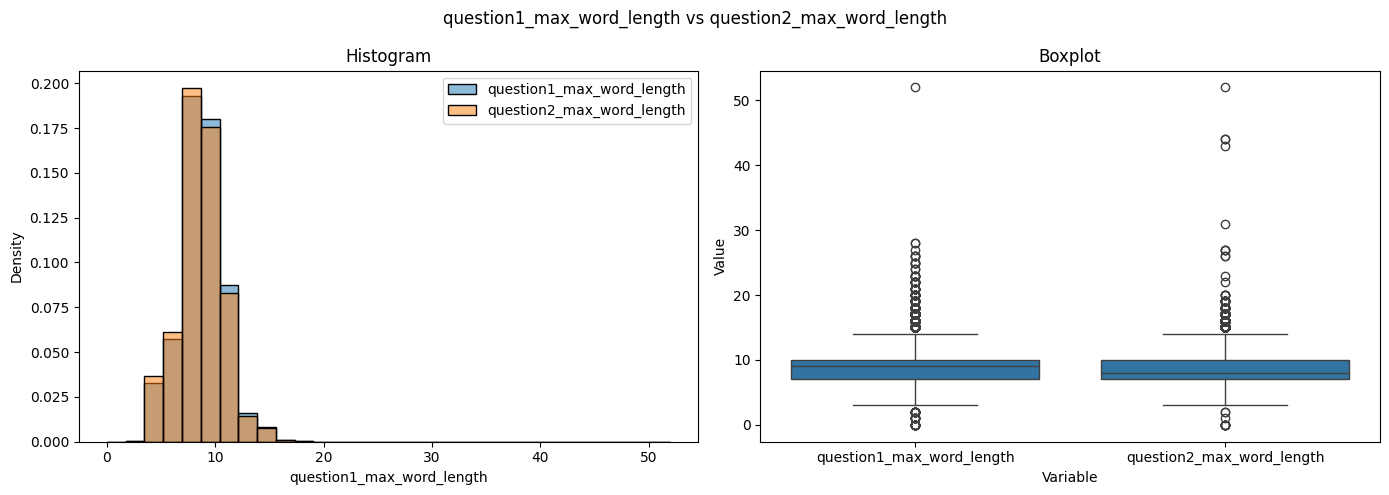

In [20]:
print("Question length distribution")
display(question_stats_df[['question1_char_count', 'question2_char_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df['question1_char_count'], question_stats_df['question2_char_count'])

print("Word count distribution in questions")
display(question_stats_df[['question1_word_count', 'question2_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df['question1_word_count'], question_stats_df['question2_word_count'])

print("Distribution of the number of unique words in questions")
display(question_stats_df[['question1_unique_word_count', 'question2_unique_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df['question1_unique_word_count'], question_stats_df['question2_unique_word_count'])

print("Distribution of average word lengths in questions")
display(question_stats_df[['question1_avg_word_length', 'question2_avg_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df['question1_avg_word_length'], question_stats_df['question2_avg_word_length'])

print("Distribution of maximum word length in questions")
display(question_stats_df[['question1_max_word_length', 'question2_max_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df['question1_max_word_length'], question_stats_df['question2_max_word_length'])

### Analysis without stop words

In [21]:
question_nosw_stats_df = question_stats(processed_nosw_df)
question_nosw_stats_df.head(3)

,qid1,qid2,question1,question2,is_duplicate,question1_tokens,question2_tokens,question1_char_count,question1_word_count,question1_unique_word_count,question1_unique_ratio,question1_avg_word_length,question1_max_word_length,question2_char_count,question2_word_count,question2_unique_word_count,question2_unique_ratio,question2_avg_word_length,question2_max_word_length
id,,,,,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0,"[iliad, odyssey, greek, culture]","[prove, pairs, three, independent, variables, also, independent]",47,4,4,1.0,6.000000,7,81,7,6,0.857143,7.142857,11
196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0,"[practical, management, strategic, management]","[practical, aspects, strategic, management]",62,4,3,0.75,9.500000,10,55,4,4,1.0,8.750000,10
113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0,"[useful, makeuseof, answers]","[q, site, yahoo, answers, hate, speech, allowed]",32,3,3,1.0,7.333333,9,78,7,7,1.0,4.857143,7


Question length distribution


,question1_char_count,question2_char_count
count,323432.00,323432.00
mean,59.53,60.12
std,29.92,33.89
min,0.00,0.00
50%,52.00,51.00
90%,99.00,103.00
99%,150.00,171.00
max,623.00,1169.00


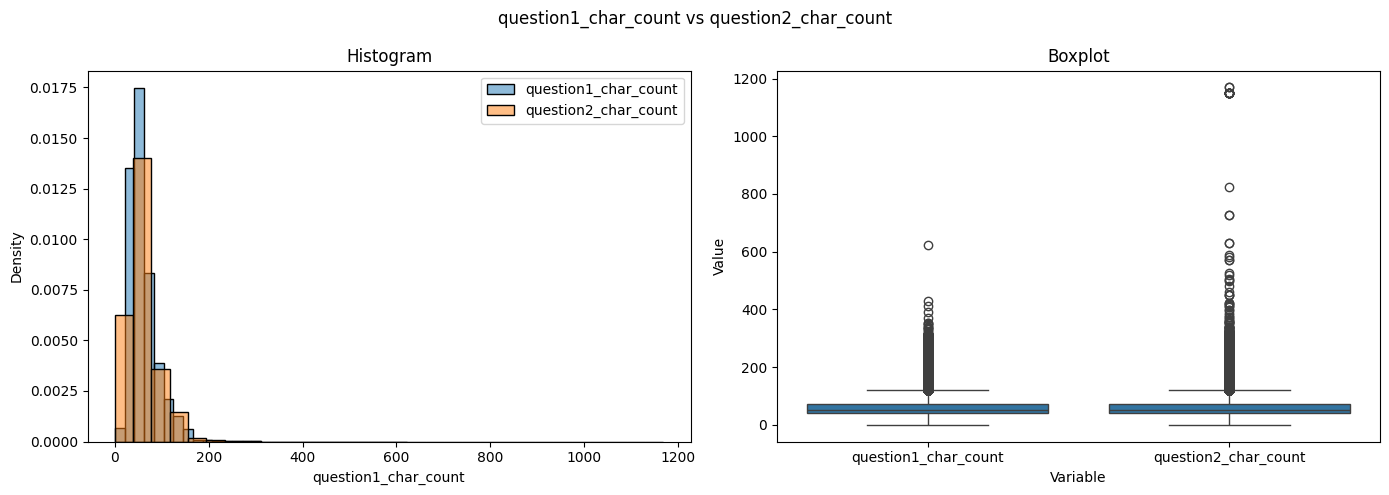

Word count distribution in questions


,question1_word_count,question2_word_count
count,323432.00,323432.00
mean,5.39,5.45
std,2.88,3.18
min,0.00,0.00
50%,5.00,5.00
90%,9.00,9.00
99%,15.00,16.00
max,52.00,97.00


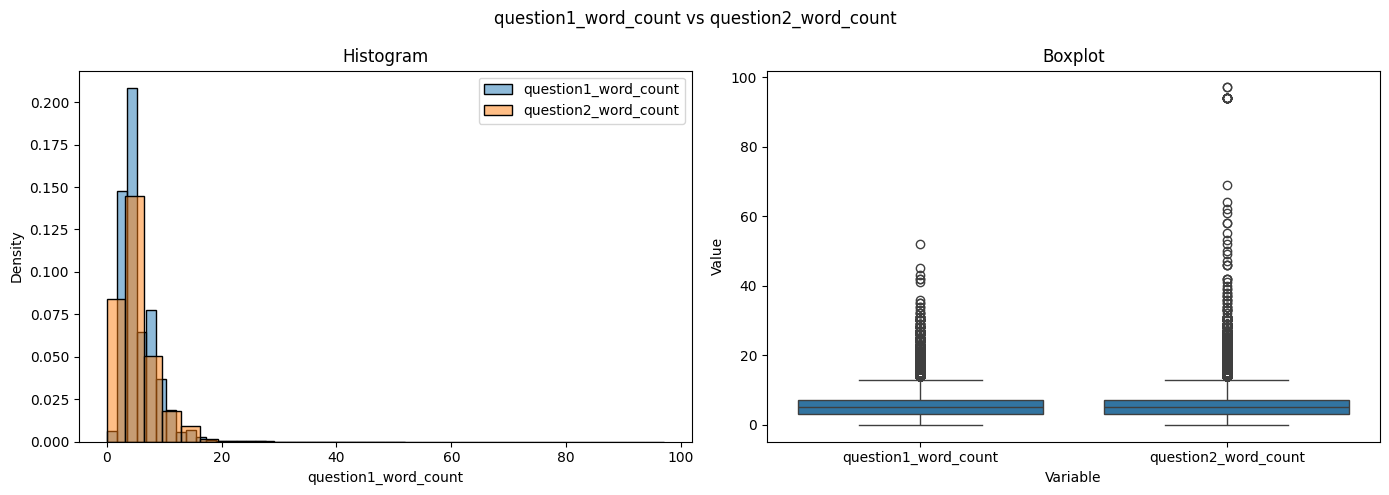

Distribution of the number of unique words in questions


,question1_unique_word_count,question2_unique_word_count
count,323432.00,323432.00
mean,5.24,5.28
std,2.67,2.90
min,0.00,0.00
50%,5.00,5.00
90%,9.00,9.00
99%,14.00,15.00
max,50.00,80.00


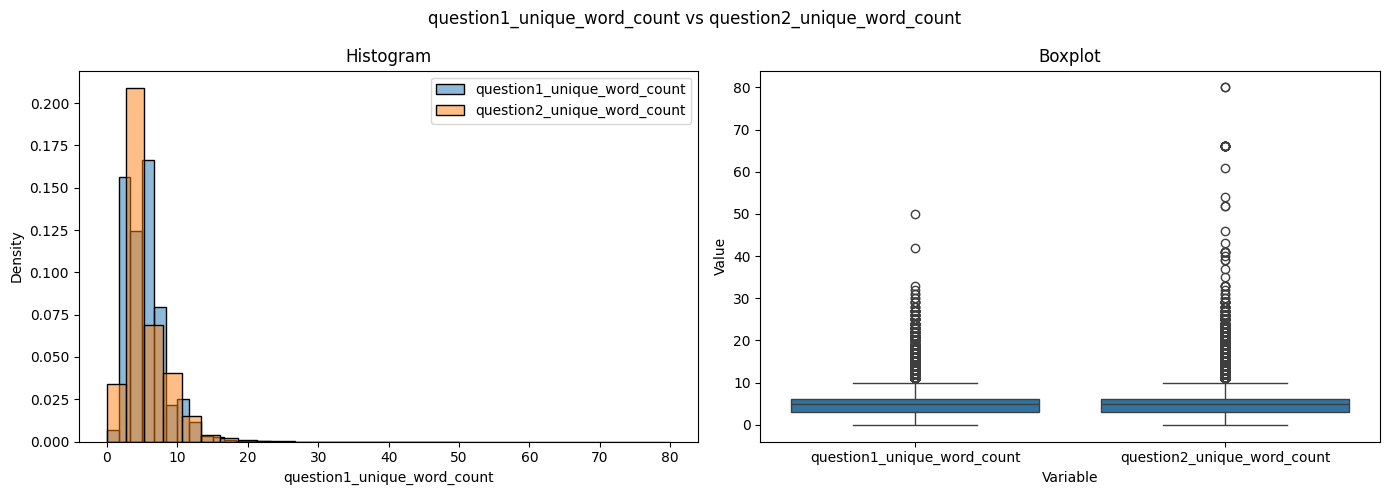

Distribution of average word lengths in questions


,question1_avg_word_length,question2_avg_word_length
count,323432.00,323432.00
mean,6.00,5.93
std,1.28,1.26
min,0.00,0.00
50%,5.91,5.80
90%,7.60,7.50
99%,9.67,9.67
max,24.00,17.00


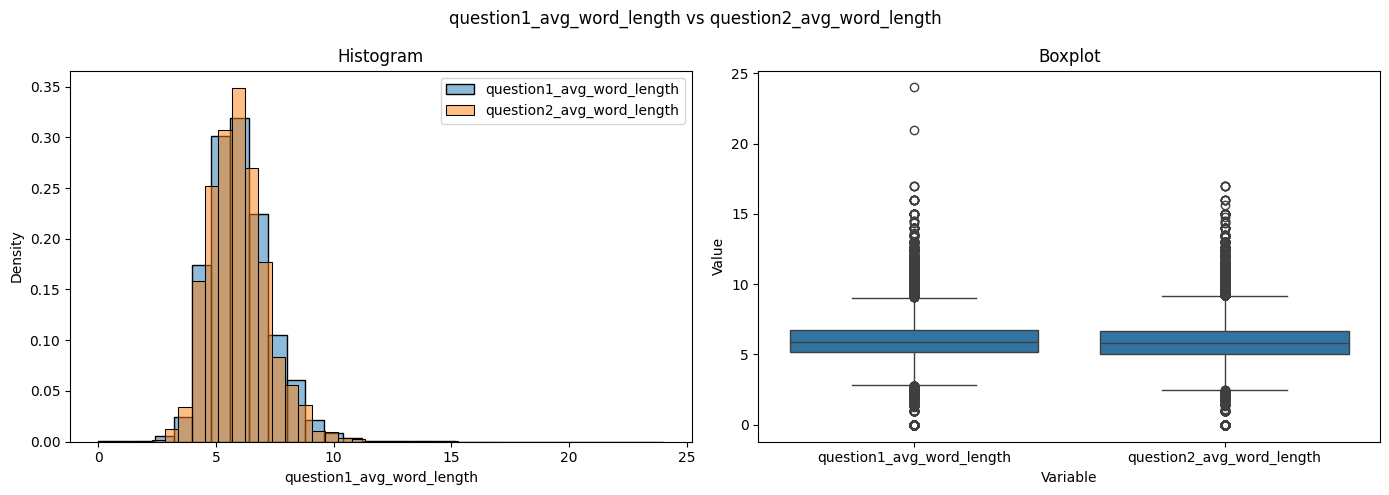

Distribution of maximum word length in questions


,question1_max_word_length,question2_max_word_length
count,323432.00,323432.00
mean,8.65,8.54
std,2.19,2.17
min,0.00,0.00
50%,9.00,8.00
90%,11.00,11.00
99%,14.00,14.00
max,52.00,52.00


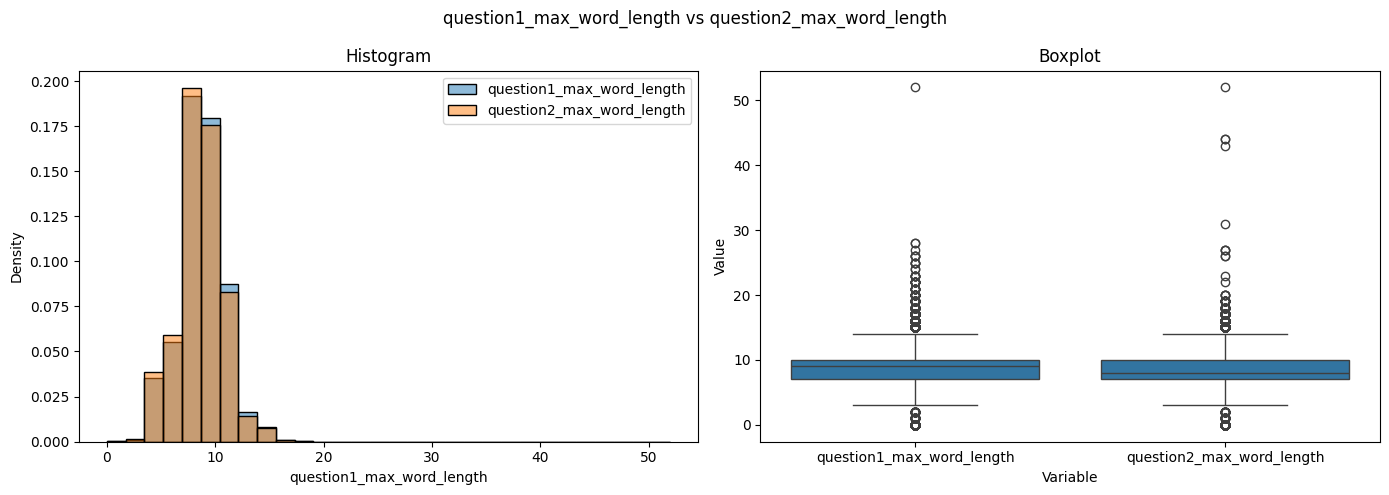

In [22]:
print("Question length distribution")
display(question_nosw_stats_df[['question1_char_count', 'question2_char_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df['question1_char_count'], question_nosw_stats_df['question2_char_count'])

print("Word count distribution in questions")
display(question_nosw_stats_df[['question1_word_count', 'question2_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df['question1_word_count'], question_nosw_stats_df['question2_word_count'])

print("Distribution of the number of unique words in questions")
display(question_nosw_stats_df[['question1_unique_word_count', 'question2_unique_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df['question1_unique_word_count'], question_nosw_stats_df['question2_unique_word_count'])

print("Distribution of average word lengths in questions")
display(question_nosw_stats_df[['question1_avg_word_length', 'question2_avg_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df['question1_avg_word_length'], question_nosw_stats_df['question2_avg_word_length'])

print("Distribution of maximum word length in questions")
display(question_nosw_stats_df[['question1_max_word_length', 'question2_max_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df['question1_max_word_length'], question_nosw_stats_df['question2_max_word_length'])

**Observation**
- The questions in the first and second columns have a fairly similar distribution of data, the only question in the second column is characterized by a longer set of both characters and words.

## Overlapping words between a pair of questions

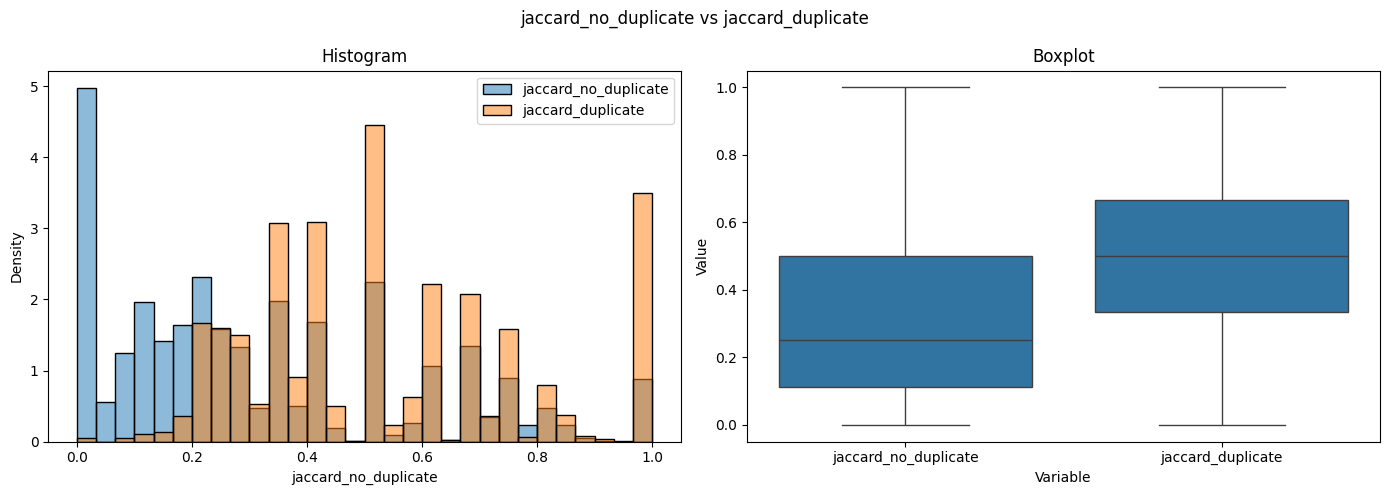

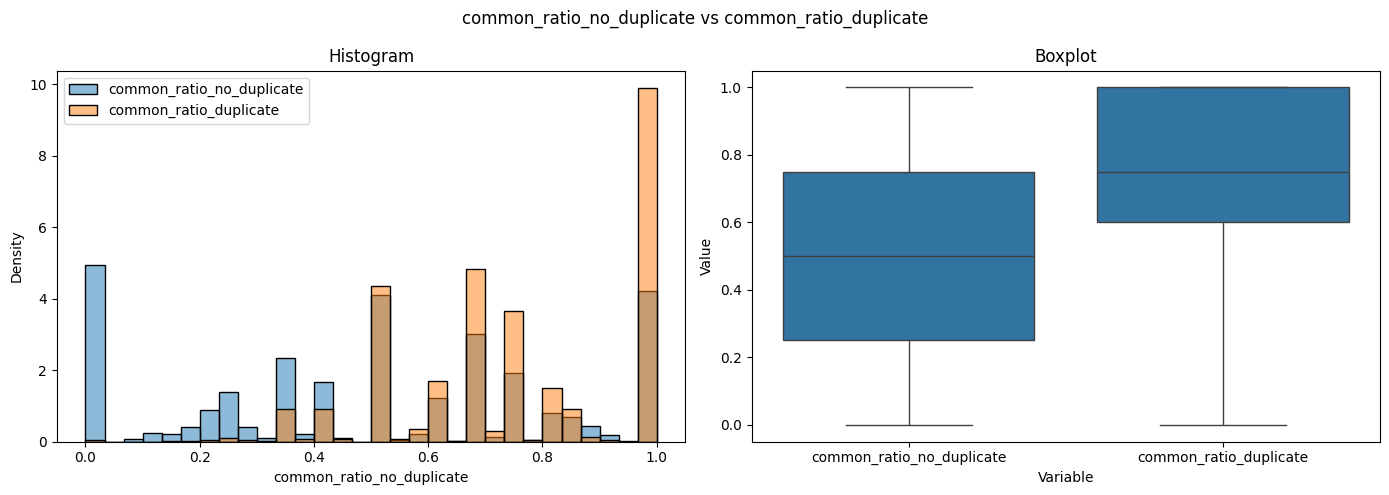

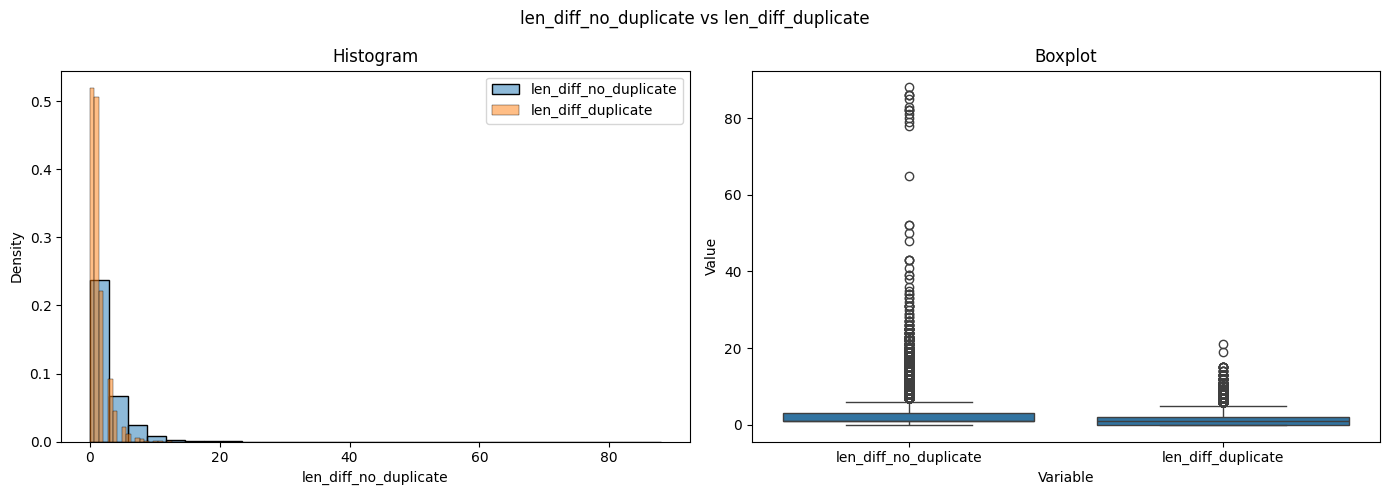

jaccard: p-value = 0.00e+00
common_ratio: p-value = 0.00e+00
len_diff_words: p-value = 0.00e+00
len_diff_chars: p-value = 0.00e+00


In [23]:
overlap_df = word_overlap_features(processed_nosw_df)

# Comparing the Jaccard similarity distribution across classes
distribution_plot(
    overlap_df.loc[overlap_df['is_duplicate'] == 0, 'jaccard'].rename('jaccard_no_duplicate'),
    overlap_df.loc[overlap_df['is_duplicate'] == 1, 'jaccard'].rename('jaccard_duplicate')
)

distribution_plot(
    overlap_df.loc[overlap_df['is_duplicate'] == 0, 'common_ratio'].rename('common_ratio_no_duplicate'),
    overlap_df.loc[overlap_df['is_duplicate'] == 1, 'common_ratio'].rename('common_ratio_duplicate')
)

distribution_plot(
    overlap_df.loc[overlap_df['is_duplicate'] == 0, 'len_diff_words'].rename('len_diff_no_duplicate'),
    overlap_df.loc[overlap_df['is_duplicate'] == 1, 'len_diff_words'].rename('len_diff_duplicate')
)

# Statistical test of the difference of distributions
for feature in ["jaccard", "common_ratio", "len_diff_words", "len_diff_chars"]:
    group0 = overlap_df.loc[overlap_df['is_duplicate'] == 0, feature].dropna()
    group1 = overlap_df.loc[overlap_df['is_duplicate'] == 1, feature].dropna()
    stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    print(f"{feature}: p-value = {p:.2e}")

**Observation:**
- According to the Jaccard distribution, questions that are classified as non-duplicates have a smaller proportion of identical words compared to questions that are duplicates, in such cases their proportion can approach unity.
- This fact is also confirmed by common_ratio, which takes a question of shorter length as a basis and finds the proportion of identical words in a longer question, neutralizing the effect of adding additional context to the essence of the same question.
- Duplicate questions are usually shorter compared to unique questions.

# Class distribution

In [24]:
class_count = df['is_duplicate'].value_counts()
class_share = df['is_duplicate'].value_counts(normalize=True)

class_balance = pd.DataFrame({"Count": class_count, "Proportion": class_share.round(4)})
class_balance

,Count,Proportion
is_duplicate,,
0,204022,0.6308
1,119410,0.3692


**Observation:**
- The distribution of the target variable is 63.08% negative class to 36.92% positive, which reflects a slight imbalance of classes, but acceptable for modeling without applying class balancing methods.

In [25]:
df0 = df[df['is_duplicate'] == 0]
df1 = df[df['is_duplicate'] == 1]

In [26]:
processed_df0 = processed_df[processed_df['is_duplicate'] == 0]
processed_df1 = processed_df[processed_df['is_duplicate'] == 1]

processed_nosw_df0 = processed_nosw_df[processed_nosw_df['is_duplicate'] == 0]
processed_nosw_df1 = processed_nosw_df[processed_nosw_df['is_duplicate'] == 1]

question_stats_df0 = question_stats_df[question_stats_df['is_duplicate'] == 0]
question_stats_df1 = question_stats_df[question_stats_df['is_duplicate'] == 1]

question_nosw_stats_df0 = question_nosw_stats_df[question_nosw_stats_df['is_duplicate'] == 0]
question_nosw_stats_df1 = question_nosw_stats_df[question_nosw_stats_df['is_duplicate'] == 1]


## Class 0 Analysis - Unique Question Pairs

In [27]:
df0[['question1', 'question2', 'is_duplicate']].head()

,question1,question2,is_duplicate
id,,,
332278,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0
196656,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0
113125,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0
266232,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0
250052,I got a seat in engineering management in Kettering University. Is that good to go? Will that build my career? What opportunities will I have after doing that course?,I am a petroleum engineer. Got an offer from Scotland University for energy economics course. Should I go there? What are the job opportunities?,0


Distribution of the length of the first question


count    204021.00
mean         63.45
std          32.54
min           1.00
50%          55.00
90%         108.00
99%         159.00
max         623.00
Name: question1, dtype: float64

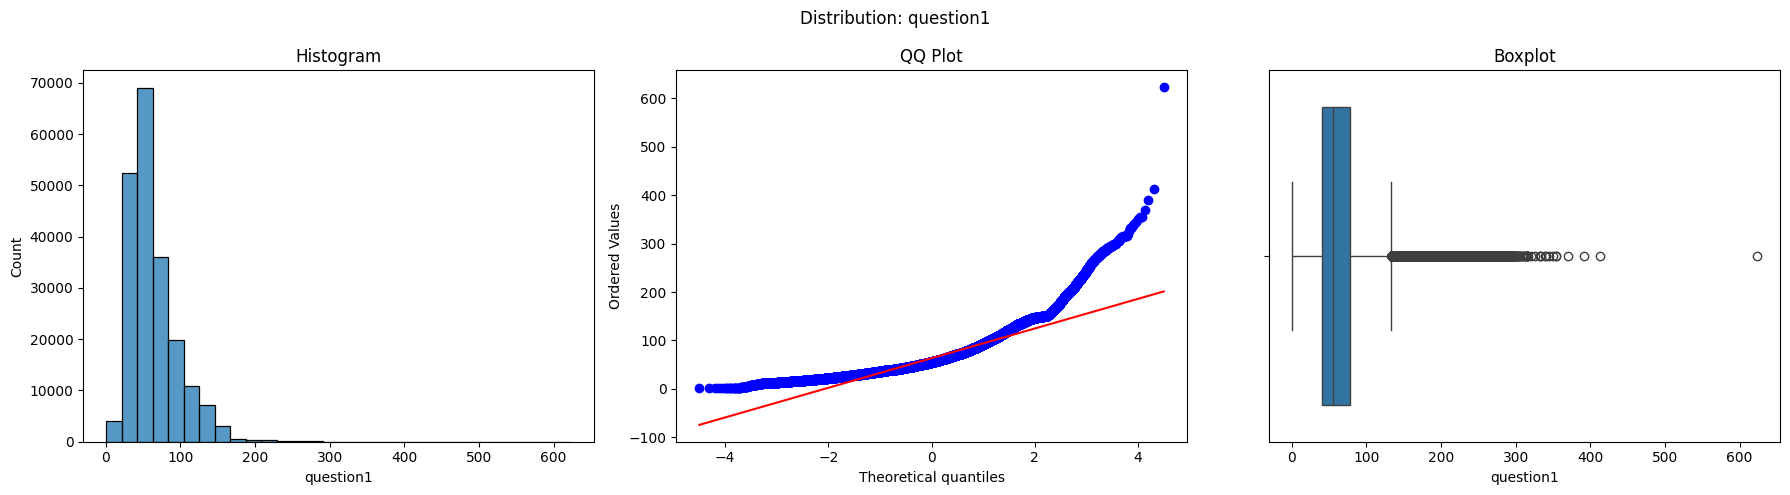

Distribution of the length of the second question


count    204020.00
mean         64.34
std          38.16
min           1.00
50%          53.00
90%         115.00
99%         193.00
max        1169.00
Name: question2, dtype: float64

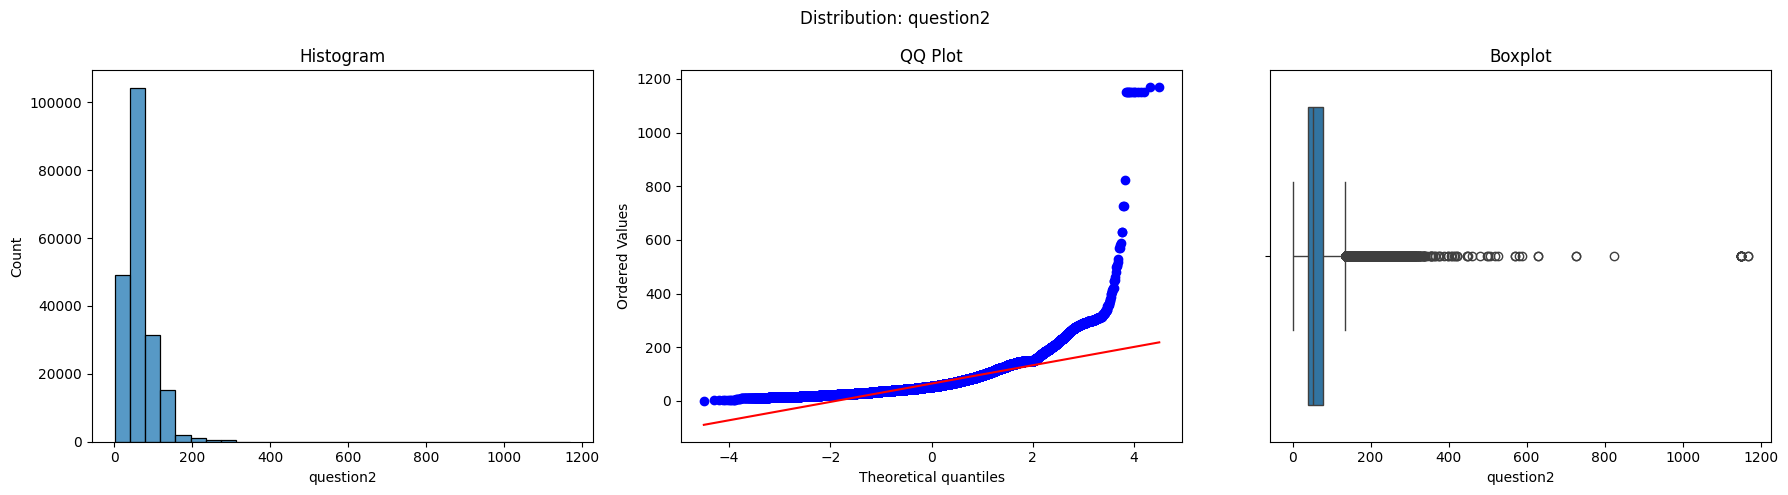

In [28]:
q1_0_len = df0['question1'].str.len()
q2_0_len = df0['question2'].str.len()

print("Distribution of the length of the first question")
display(q1_0_len.describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(q1_0_len)

print("Distribution of the length of the second question")
display(q2_0_len.describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(q2_0_len)

### Semantic analysis of the sample

#### Analysis with stop words

In [29]:
word0_frequency = corpus_word_frequency(processed_df0)

print("Sample dictionary size:", len(word0_frequency))
print("Proportion of rare words that occur 1 time:", round(rare_words_ratio(word0_frequency), 4))

freq_df0 = frequency_df(word0_frequency)

print("Most frequently used words")
display(freq_df0.head(10))

print("Least frequently used words")
display(freq_df0.tail(10))

Sample dictionary size: 69320
Proportion of rare words that occur 1 time: 0.4036
Most frequently used words


,word,frequency,share_percent
0,the,195535,4.0459
1,what,165509,3.4246
2,is,153380,3.1737
3,a,125067,2.5878
4,i,119742,2.4776
5,to,111389,2.3048
6,in,111298,2.3029
7,how,104664,2.1657
8,of,86133,1.7822
9,do,83815,1.7343


Least frequently used words


,word,frequency,share_percent
69310,非洲,1,0.0
69311,bromhexine,1,0.0
69312,phsychiatrist,1,0.0
69313,relieves,1,0.0
69314,hashes,1,0.0
69315,pips,1,0.0
69316,mrec,1,0.0
69317,medallion,1,0.0
69318,offends,1,0.0
69319,heptarchy,1,0.0


#### Analysis without stop words

In [30]:
word0_nosw_frequency = corpus_word_frequency(processed_nosw_df0)

print("Sample dictionary size excluding stop words:", len(word0_nosw_frequency))
print("The proportion of rare words that occur once, excluding stop words:", round(rare_words_ratio(word0_nosw_frequency), 4))

freq_nosw_df0 = frequency_df(word0_nosw_frequency)

print("Most frequently used words excluding stop words")
display(freq_nosw_df0.head(10))

print("Least frequently used words excluding stop words")
display(freq_nosw_df0.tail(10))

Sample dictionary size excluding stop words: 69181
The proportion of rare words that occur once, excluding stop words: 0.4044
Most frequently used words excluding stop words


,word,frequency,share_percent
0,best,28926,1.2169
1,get,19721,0.8297
2,like,15072,0.6341
3,good,13867,0.5834
4,india,13161,0.5537
5,would,12557,0.5283
6,people,12523,0.5269
7,one,10596,0.4458
8,make,8777,0.3693
9,much,7765,0.3267


Least frequently used words excluding stop words


,word,frequency,share_percent
69171,humanzee,1,0.0
69172,kolkta,1,0.0
69173,ehrs,1,0.0
69174,emrs,1,0.0
69175,jaruk,1,0.0
69176,sponsorchat,1,0.0
69177,askapatient,1,0.0
69178,wacc,1,0.0
69179,calabases,1,0.0
69180,makeuseof,1,0.0


### Analysis of individual issues

#### Analysis with stop words

Question length distribution


,question1_char_count,question2_char_count
count,204022.00,204022.00
mean,63.45,64.34
std,32.54,38.16
min,0.00,0.00
50%,55.00,53.00
90%,108.00,115.00
99%,159.00,193.00
max,623.00,1169.00


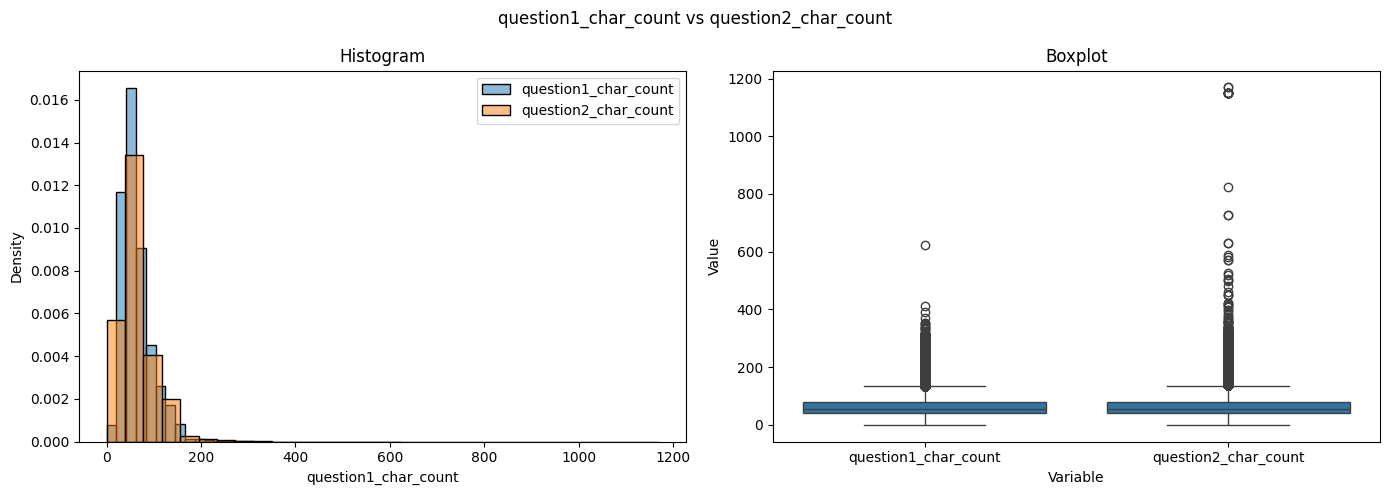

Word count distribution in questions


,question1_word_count,question2_word_count
count,204022.00,204022.00
mean,11.65,12.03
std,5.99,7.25
min,0.00,0.00
50%,10.00,10.00
90%,20.00,21.00
99%,31.00,37.00
max,127.00,245.00


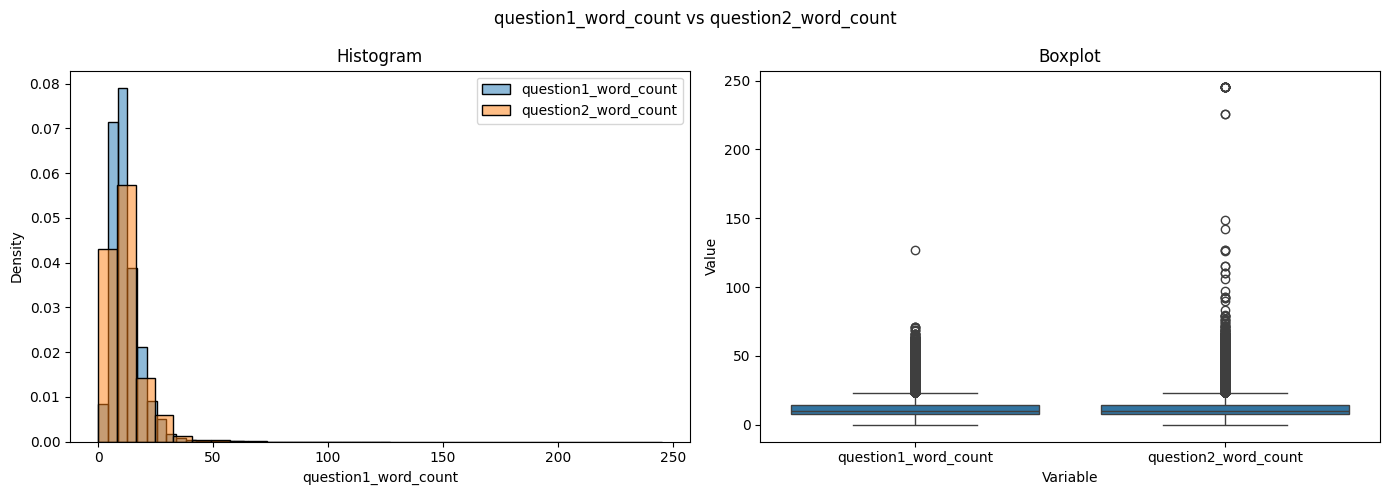

Distribution of the number of unique words in questions


,question1_unique_word_count,question2_unique_word_count
count,204022.00,204022.00
mean,10.97,11.23
std,5.00,5.74
min,0.00,0.00
50%,10.00,10.00
90%,18.00,19.00
99%,26.00,30.00
max,93.00,127.00


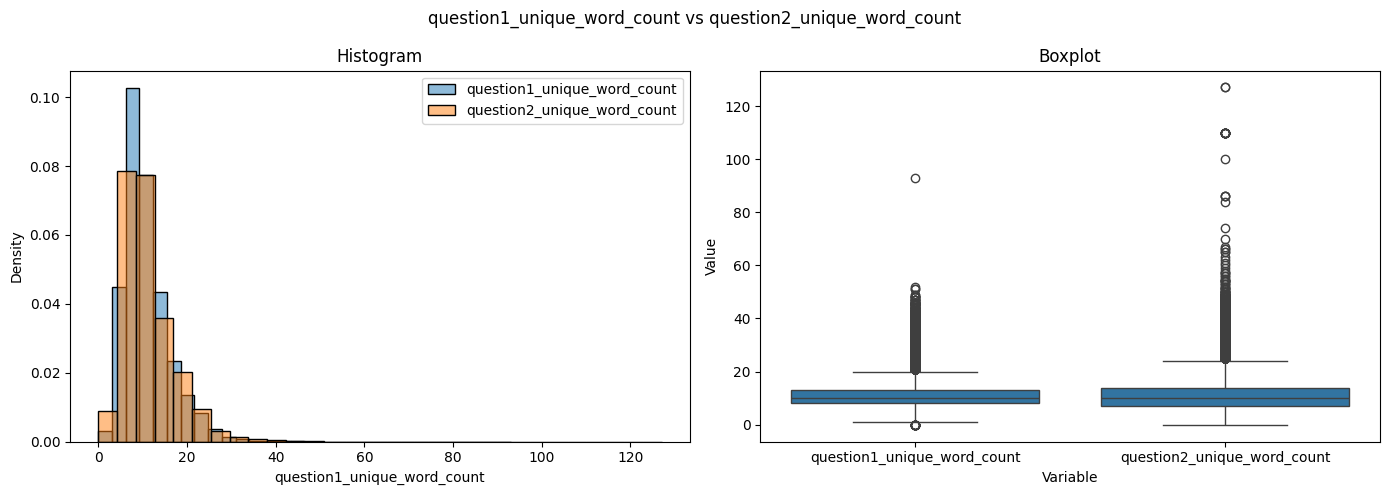

Distribution of average word lengths in questions


,question1_avg_word_length,question2_avg_word_length
count,204022.00,204022.00
mean,4.41,4.31
std,0.78,0.76
min,0.00,0.00
50%,4.33,4.25
90%,5.41,5.29
99%,6.57,6.45
max,11.00,15.67


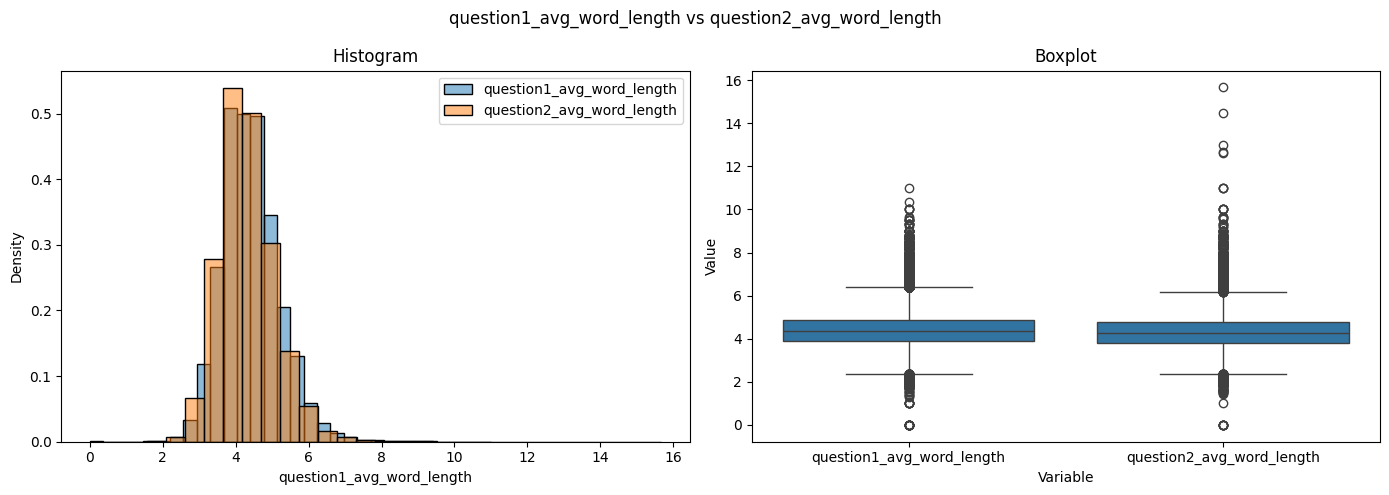

Distribution of maximum word length in questions


,question1_max_word_length,question2_max_word_length
count,204022.00,204022.00
mean,8.81,8.63
std,2.16,2.14
min,0.00,0.00
50%,9.00,9.00
90%,12.00,11.00
99%,14.00,14.00
max,28.00,44.00


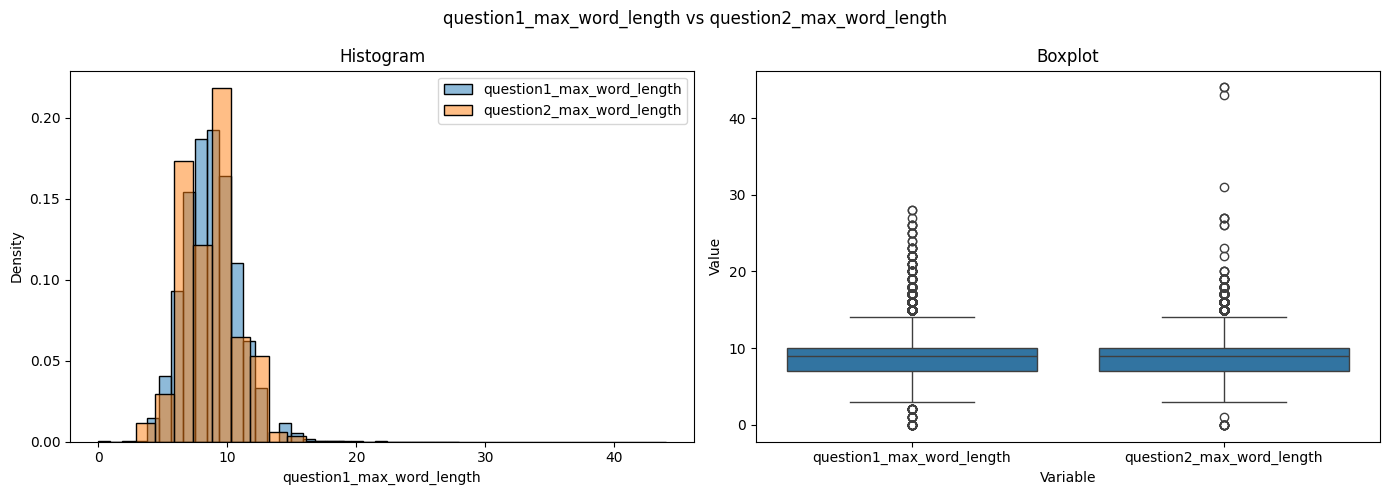

In [31]:
print("Question length distribution")
display(question_stats_df0[['question1_char_count', 'question2_char_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df0['question1_char_count'], question_stats_df0['question2_char_count'])

print("Word count distribution in questions")
display(question_stats_df0[['question1_word_count', 'question2_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df0['question1_word_count'], question_stats_df0['question2_word_count'])

print("Distribution of the number of unique words in questions")
display(question_stats_df0[['question1_unique_word_count', 'question2_unique_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df0['question1_unique_word_count'], question_stats_df0['question2_unique_word_count'])

print("Distribution of average word lengths in questions")
display(question_stats_df0[['question1_avg_word_length', 'question2_avg_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df0['question1_avg_word_length'], question_stats_df0['question2_avg_word_length'])

print("Distribution of maximum word length in questions")
display(question_stats_df0[['question1_max_word_length', 'question2_max_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df0['question1_max_word_length'], question_stats_df0['question2_max_word_length'])

#### Analysis without stop words

Question length distribution


,question1_char_count,question2_char_count
count,204022.00,204022.00
mean,63.45,64.34
std,32.54,38.16
min,0.00,0.00
50%,55.00,53.00
90%,108.00,115.00
99%,159.00,193.00
max,623.00,1169.00


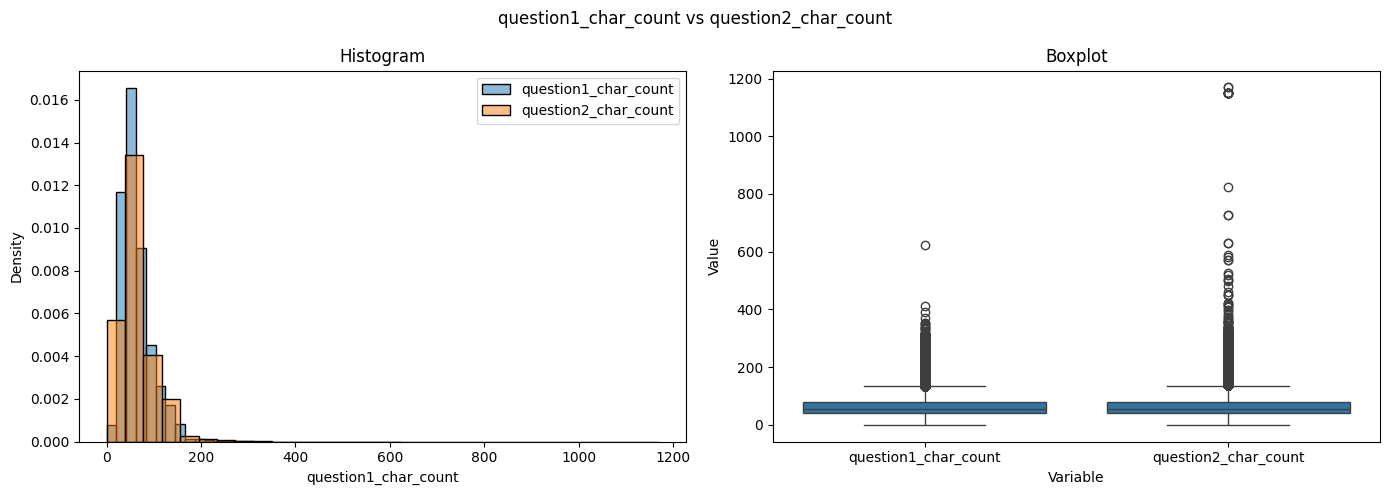

Word count distribution in questions


,question1_word_count,question2_word_count
count,204022.00,204022.00
mean,5.78,5.87
std,3.14,3.55
min,0.00,0.00
50%,5.00,5.00
90%,10.00,10.00
99%,16.00,18.00
max,52.00,97.00


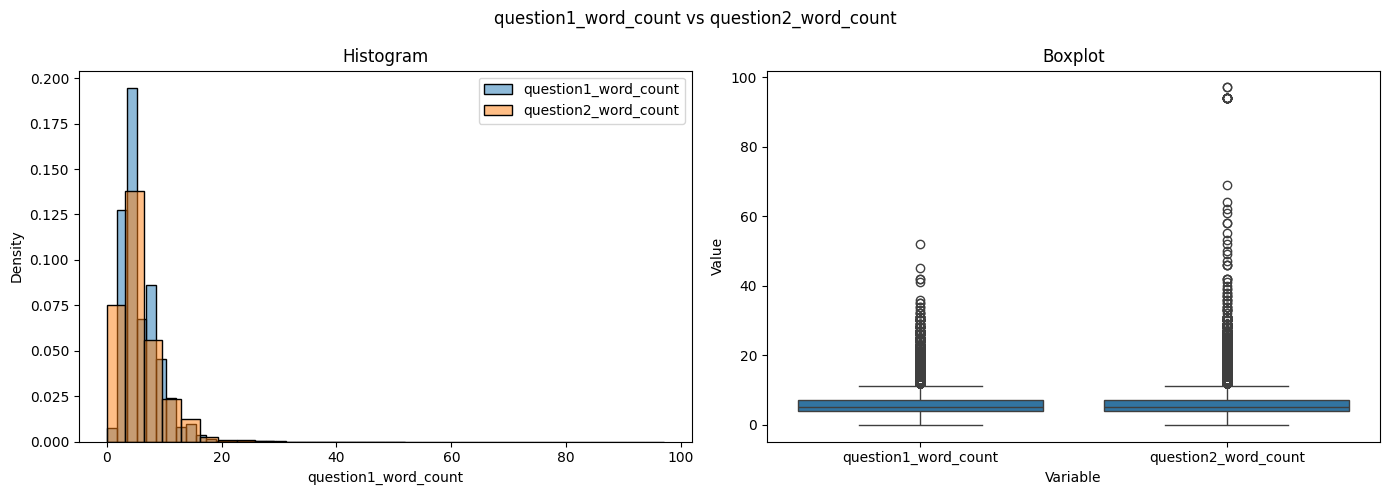

Distribution of the number of unique words in questions


,question1_unique_word_count,question2_unique_word_count
count,204022.00,204022.00
mean,5.59,5.67
std,2.90,3.22
min,0.00,0.00
50%,5.00,5.00
90%,10.00,10.00
99%,15.00,16.00
max,50.00,80.00


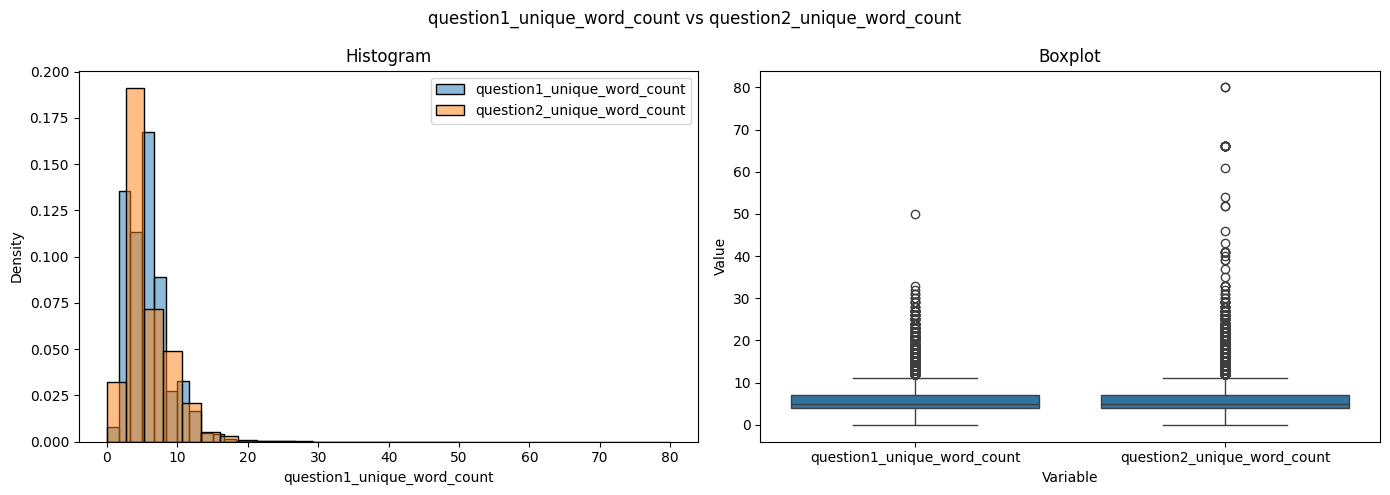

Distribution of average word lengths in questions


,question1_avg_word_length,question2_avg_word_length
count,204022.00,204022.00
mean,6.03,5.91
std,1.29,1.26
min,0.00,0.00
50%,6.00,5.80
90%,7.67,7.50
99%,9.75,9.67
max,24.00,17.00


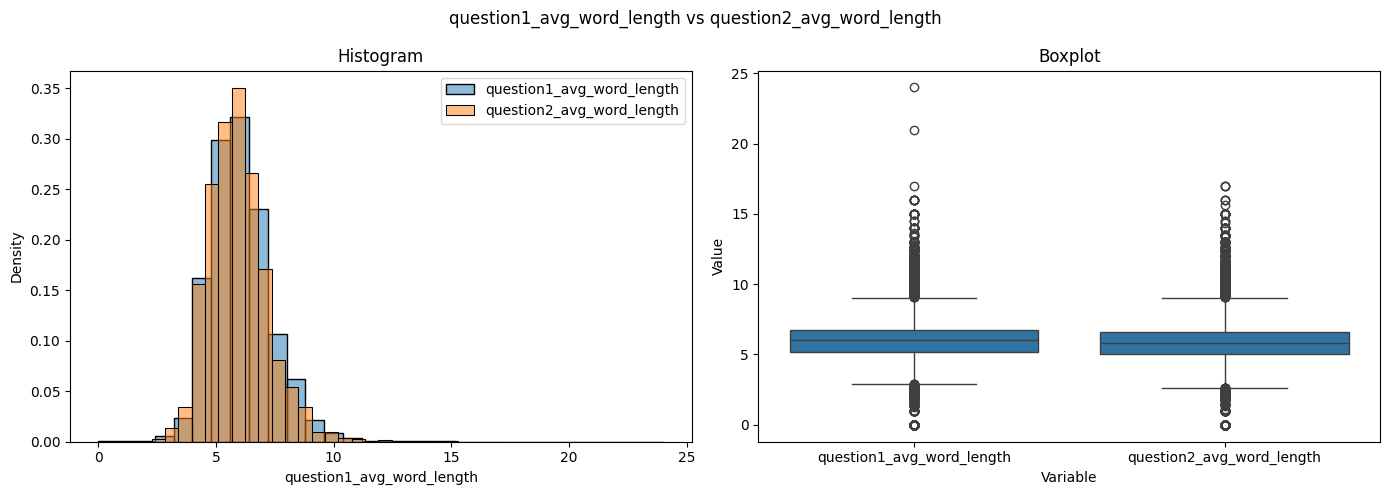

Distribution of maximum word length in questions


,question1_max_word_length,question2_max_word_length
count,204022.00,204022.00
mean,8.80,8.61
std,2.19,2.17
min,0.00,0.00
50%,9.00,9.00
90%,12.00,11.00
99%,14.00,14.00
max,28.00,44.00


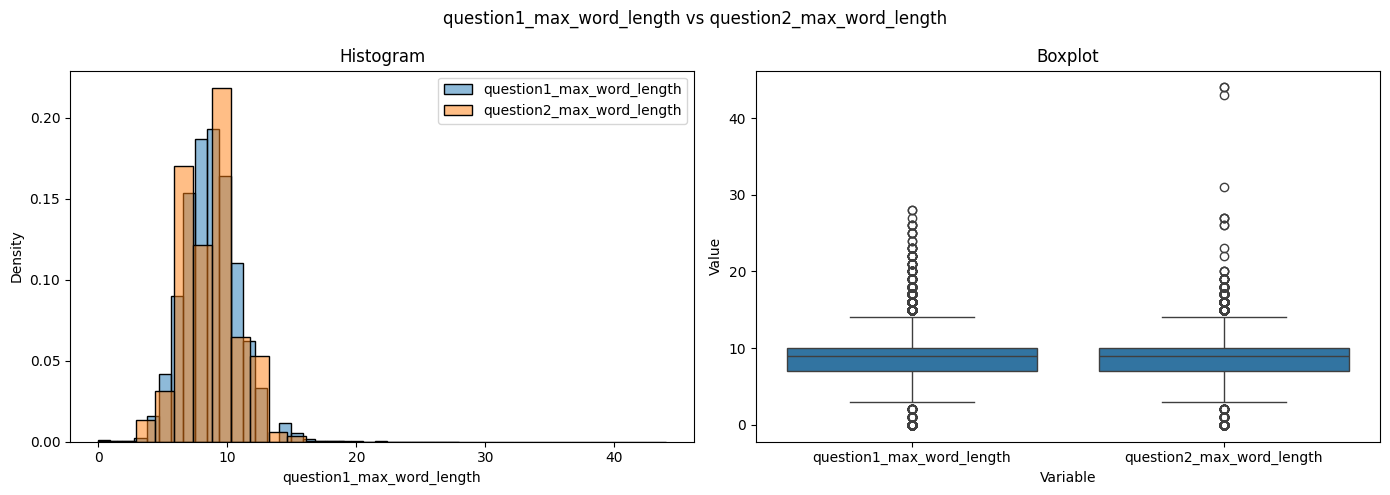

In [32]:
print("Question length distribution")
display(question_nosw_stats_df0[['question1_char_count', 'question2_char_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df0['question1_char_count'], question_nosw_stats_df0['question2_char_count'])

print("Word count distribution in questions")
display(question_nosw_stats_df0[['question1_word_count', 'question2_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df0['question1_word_count'], question_nosw_stats_df0['question2_word_count'])

print("Distribution of the number of unique words in questions")
display(question_nosw_stats_df0[['question1_unique_word_count', 'question2_unique_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df0['question1_unique_word_count'], question_nosw_stats_df0['question2_unique_word_count'])

print("Distribution of average word lengths in questions")
display(question_nosw_stats_df0[['question1_avg_word_length', 'question2_avg_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df0['question1_avg_word_length'], question_nosw_stats_df0['question2_avg_word_length'])

print("Distribution of maximum word length in questions")
display(question_nosw_stats_df0[['question1_max_word_length', 'question2_max_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df0['question1_max_word_length'], question_nosw_stats_df0['question2_max_word_length'])

## Class 1 Analysis - Duplicate Questions

In [33]:
df1[['question1', 'question2']].head()

,question1,question2
id,,
122738,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?,Why don't many people posting questions on Quora check Google first?
402631,What is the best small business to start in Nagpur?,Which business/startup should I start in Nagpur which will have best chances of survival?
346061,How can I open a PPF account? And what are its benefits?,What is PPF account?
65247,"What is the Sahara, and how do the average temperatures there compare to the ones in the Antarctica?","What is the Sahara, and how do the average temperatures there compare to the ones in the Gibson Desert?"
138940,Is a third World War imminent?,Will there be a third World War?


Distribution of the length of the first question


count    119410.00
mean         52.83
std          23.33
min           3.00
50%          47.00
90%          84.00
99%         137.00
max         430.00
Name: question1, dtype: float64

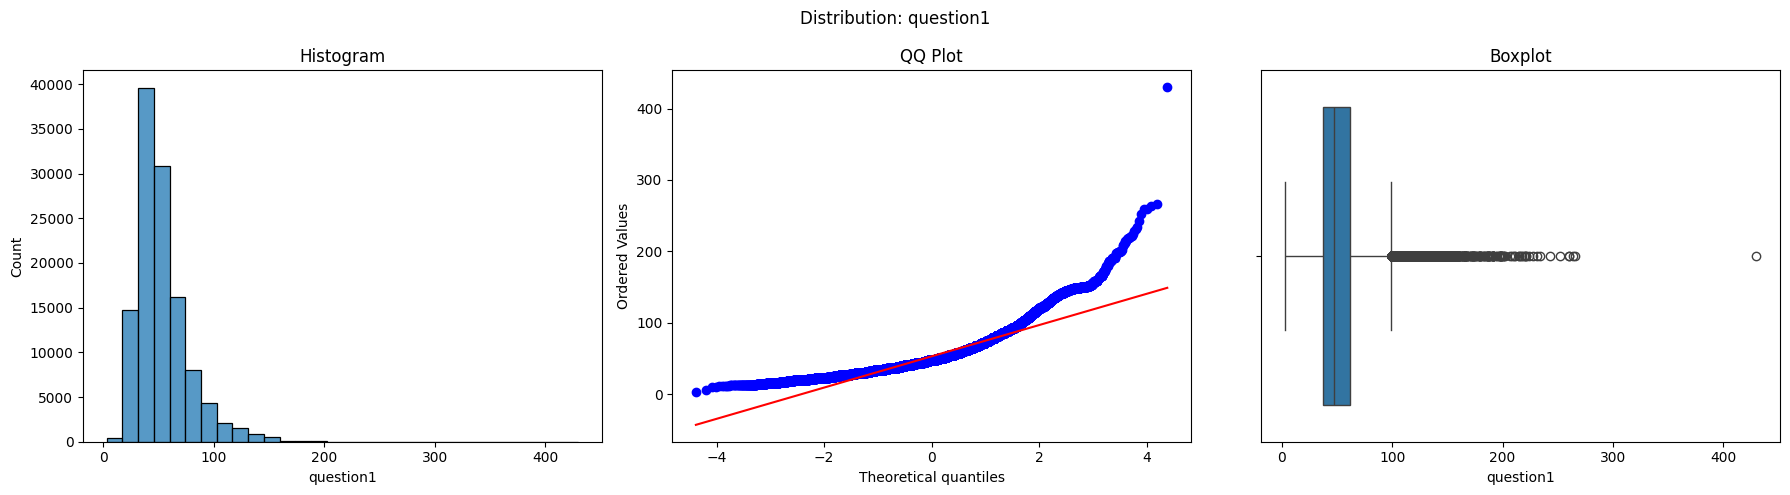

Distribution of the length of the second question


count    119410.00
mean         52.92
std          23.26
min           2.00
50%          47.00
90%          84.00
99%         136.00
max         295.00
Name: question2, dtype: float64

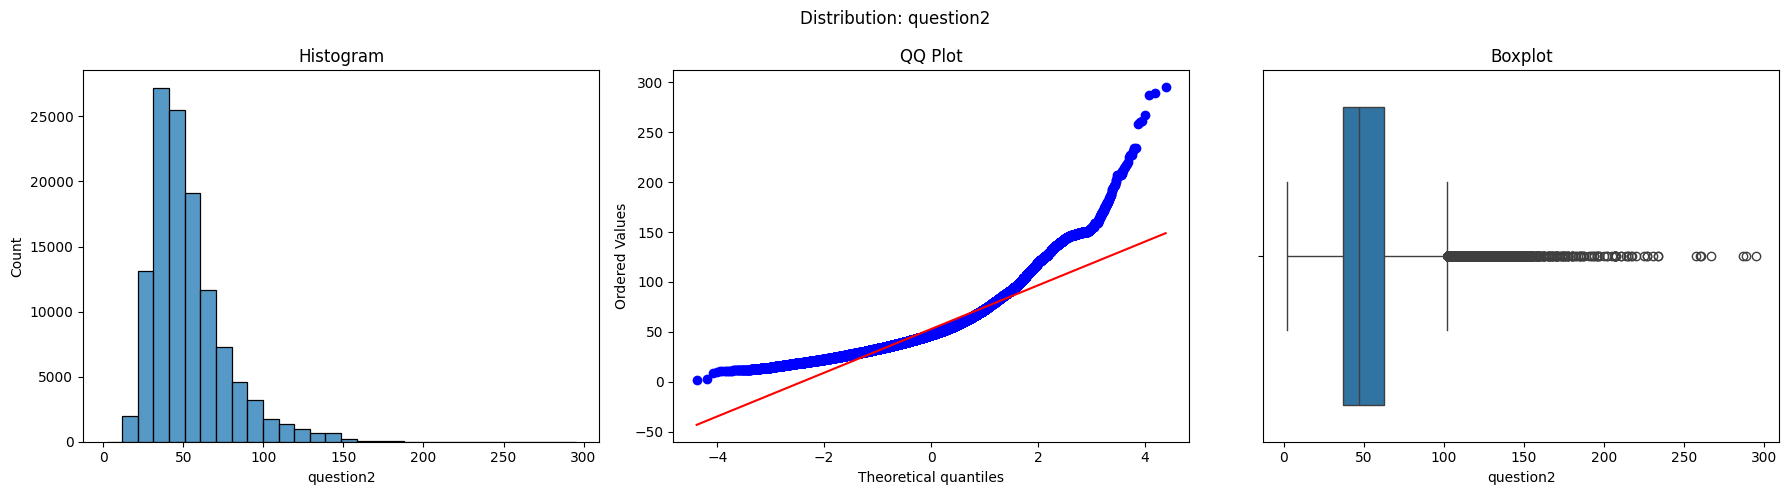

In [34]:
q1_1_len = df1['question1'].str.len()
q2_1_len = df1['question2'].str.len()

print("Distribution of the length of the first question")
display(q1_1_len.describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(q1_1_len)

print("Distribution of the length of the second question")
display(q2_1_len.describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(q2_1_len)

### Semantic analysis of the sample

#### Analysis with stop words

In [35]:
word1_frequency = corpus_word_frequency(processed_df1)

print("Sample dictionary size:", len(word1_frequency))
print("Proportion of rare words occurring 1 time:", round(rare_words_ratio(word1_frequency), 4))

freq_df1 = frequency_df(word1_frequency)

print("Most frequently used words")
display(freq_df1.head(10))

print("Least frequently used words")
display(freq_df1.tail(10))

Sample dictionary size: 26132
Proportion of rare words occurring 1 time: 0.1662
Most frequently used words


,word,frequency,share_percent
0,the,106674,4.5437
1,what,94501,4.0252
2,is,78209,3.3313
3,how,72142,3.0728
4,i,59974,2.5545
5,to,53827,2.2927
6,do,52134,2.2206
7,in,46327,1.9733
8,a,45503,1.9382
9,are,42864,1.8258


Least frequently used words


,word,frequency,share_percent
26122,tripods,1,0.0
26123,slovakia,1,0.0
26124,notebooks,1,0.0
26125,flashpoint,1,0.0
26126,sought,1,0.0
26127,chating,1,0.0
26128,amu,1,0.0
26129,permnantly,1,0.0
26130,slows,1,0.0
26131,adversity,1,0.0


#### Analysis without stop words

In [36]:
word1_nosw_frequency = corpus_word_frequency(processed_nosw_df1)

print("Dictionary size excluding stop words:", len(word1_nosw_frequency))
print("The proportion of rare words that occur once, excluding stop words:", round(rare_words_ratio(word1_nosw_frequency), 4))

freq_nosw_df1 = frequency_df(word1_nosw_frequency)

print("Most frequently used words excluding stop words")
display(freq_nosw_df1.head(10))

print("Least frequently used words excluding stop words")
display(freq_nosw_df1.tail(10))

Dictionary size excluding stop words: 25995
The proportion of rare words that occur once, excluding stop words: 0.167
Most frequently used words excluding stop words


,word,frequency,share_percent
0,best,27573,2.4466
1,get,11925,1.0581
2,india,10552,0.9363
3,quora,9877,0.8764
4,people,8665,0.7689
5,would,6797,0.6031
6,way,6756,0.5995
7,money,6742,0.5982
8,life,6460,0.5732
9,good,6132,0.5441


Least frequently used words excluding stop words


,word,frequency,share_percent
25985,adversity,1,0.0001
25986,wbengal,1,0.0001
25987,neceesary,1,0.0001
25988,interrelated,1,0.0001
25989,comiting,1,0.0001
25990,unroot,1,0.0001
25991,boutique,1,0.0001
25992,triggering,1,0.0001
25993,postmortem,1,0.0001
25994,demonstrated,1,0.0001


### Analysis of individual issues

#### Analysis with stop words

Question length distribution


,question1_char_count,question2_char_count
count,119410.00,119410.00
mean,52.83,52.92
std,23.33,23.26
min,3.00,2.00
50%,47.00,47.00
90%,84.00,84.00
99%,137.00,136.00
max,430.00,295.00


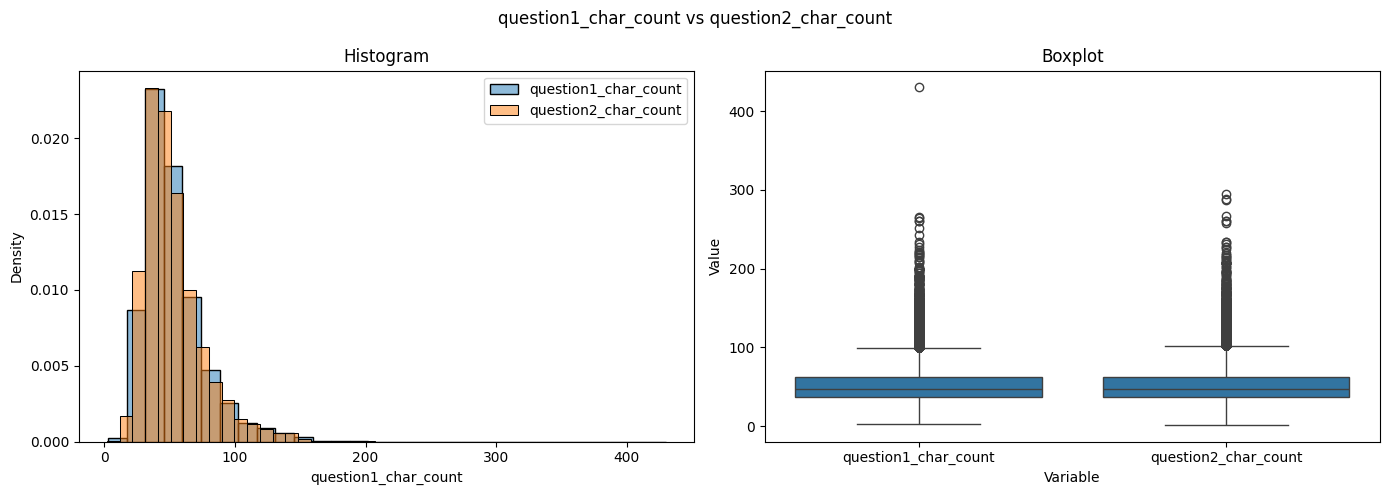

Word count distribution in questions


,question1_word_count,question2_word_count
count,119410.00,119410.00
mean,9.83,9.83
std,4.14,4.12
min,1.00,1.00
50%,9.00,9.00
90%,15.00,15.00
99%,25.00,24.00
max,81.00,62.00


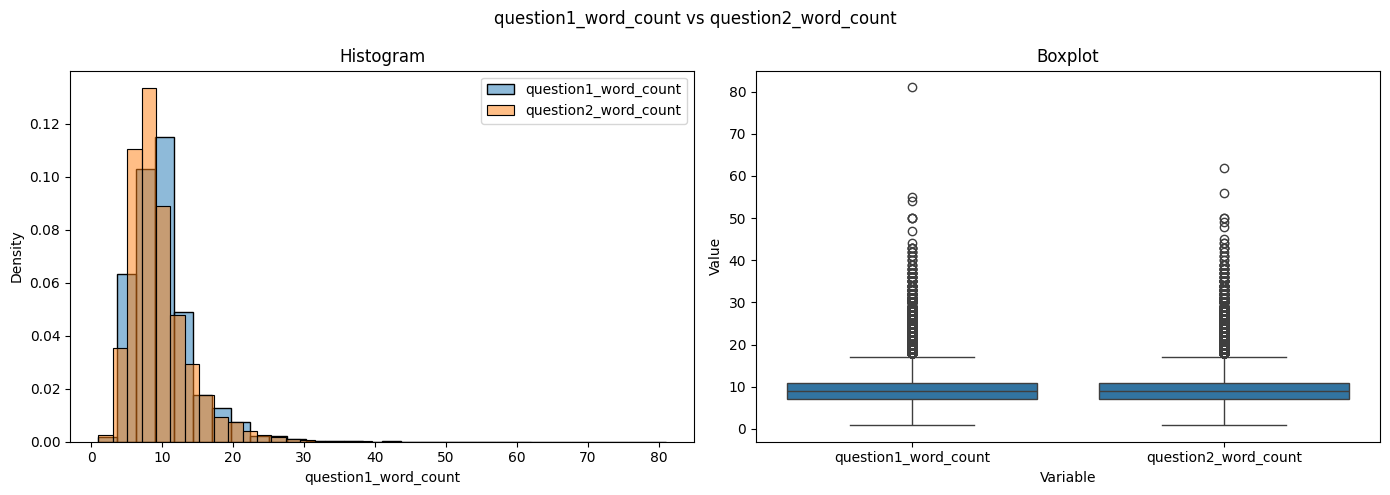

Distribution of the number of unique words in questions


,question1_unique_word_count,question2_unique_word_count
count,119410.00,119410.00
mean,9.44,9.45
std,3.56,3.55
min,1.00,1.00
50%,9.00,9.00
90%,14.00,14.00
99%,21.00,21.00
max,66.00,45.00


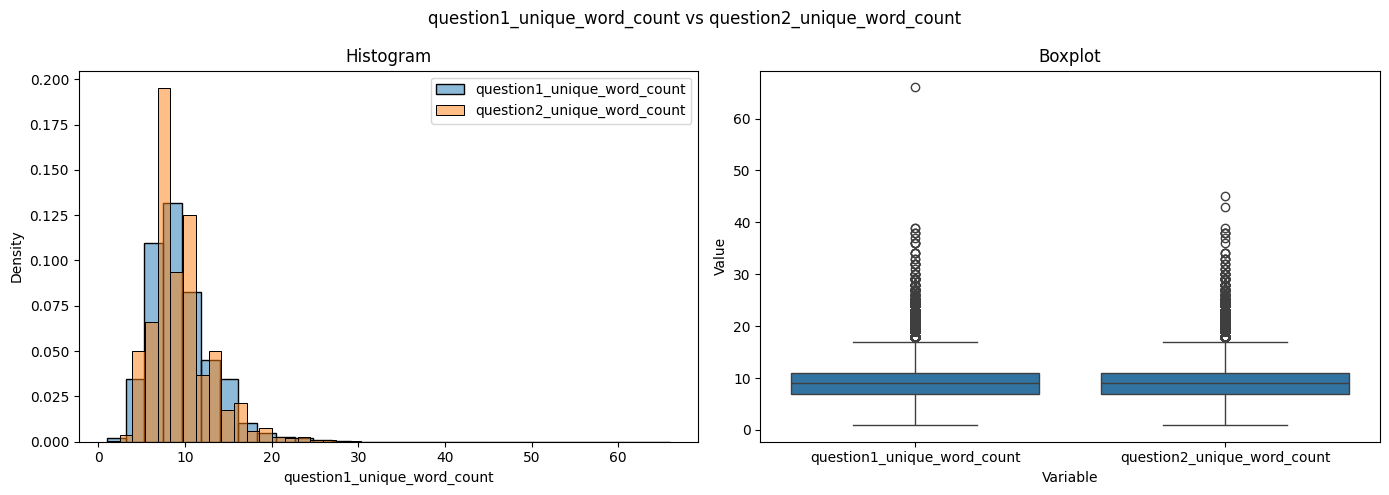

Distribution of average word lengths in questions


,question1_avg_word_length,question2_avg_word_length
count,119410.00,119410.00
mean,4.32,4.32
std,0.74,0.75
min,1.73,1.57
50%,4.25,4.27
90%,5.29,5.29
99%,6.40,6.43
max,10.50,14.75


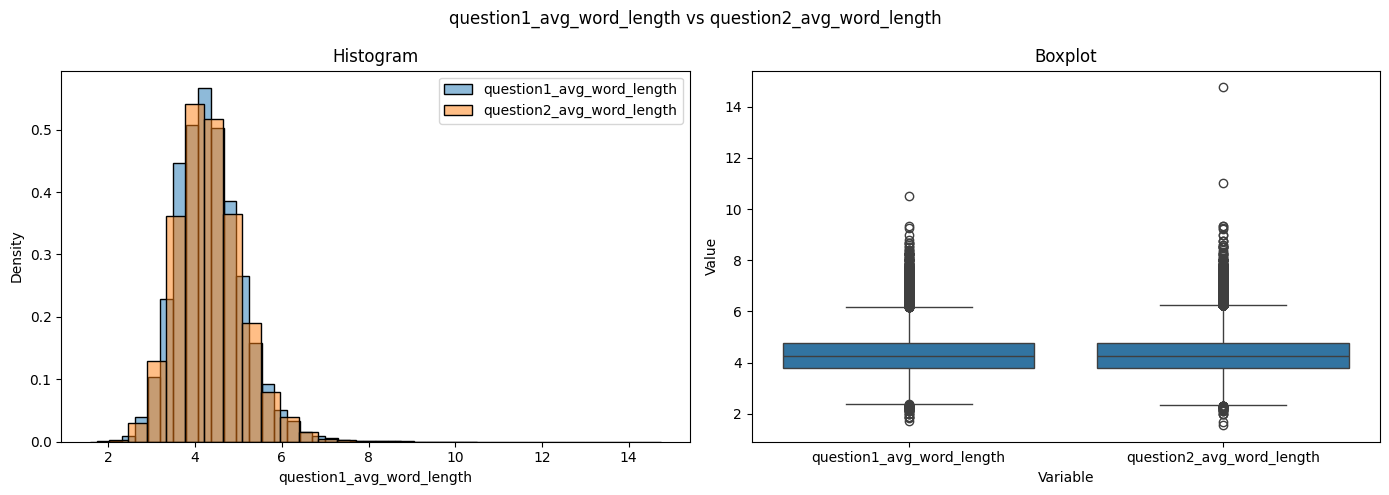

Distribution of maximum word length in questions


,question1_max_word_length,question2_max_word_length
count,119410.00,119410.00
mean,8.42,8.44
std,2.14,2.15
min,2.00,2.00
50%,8.00,8.00
90%,11.00,11.00
99%,14.00,14.00
max,52.00,52.00


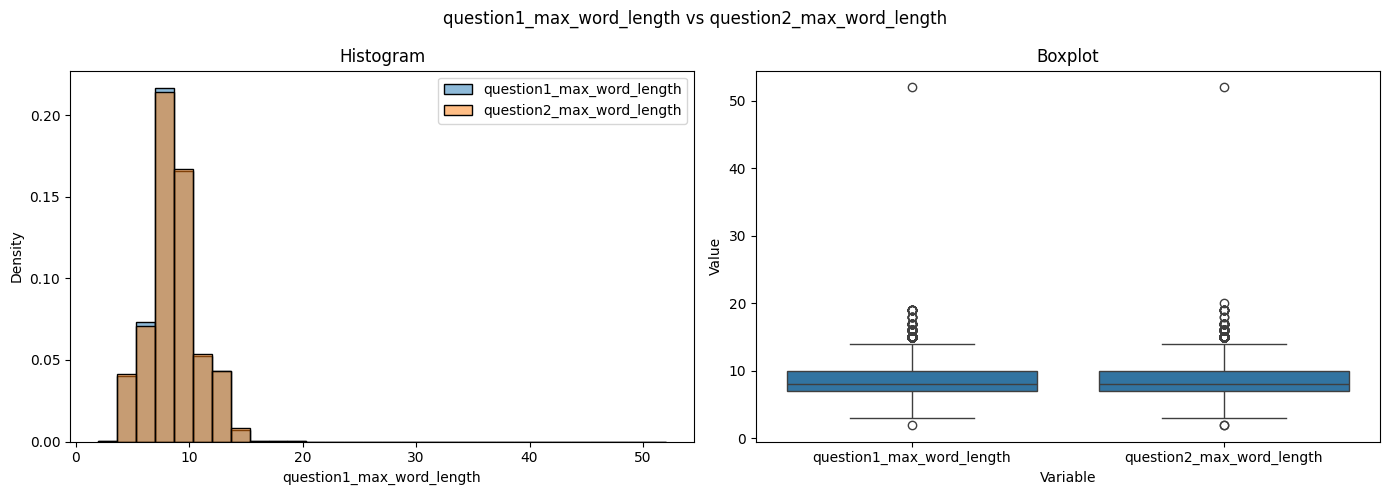

In [37]:
print("Question length distribution")
display(question_stats_df1[['question1_char_count', 'question2_char_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df1['question1_char_count'], question_stats_df1['question2_char_count'])

print("Word count distribution in questions")
display(question_stats_df1[['question1_word_count', 'question2_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df1['question1_word_count'], question_stats_df1['question2_word_count'])

print("Distribution of the number of unique words in questions")
display(question_stats_df1[['question1_unique_word_count', 'question2_unique_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df1['question1_unique_word_count'], question_stats_df1['question2_unique_word_count'])

print("Distribution of average word lengths in questions")
display(question_stats_df1[['question1_avg_word_length', 'question2_avg_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df1['question1_avg_word_length'], question_stats_df1['question2_avg_word_length'])

print("Distribution of maximum word length in questions")
display(question_stats_df1[['question1_max_word_length', 'question2_max_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_stats_df1['question1_max_word_length'], question_stats_df1['question2_max_word_length'])

#### Analysis without stop words

Question length distribution


,question1_char_count,question2_char_count
count,119410.00,119410.00
mean,52.83,52.92
std,23.33,23.26
min,3.00,2.00
50%,47.00,47.00
90%,84.00,84.00
99%,137.00,136.00
max,430.00,295.00


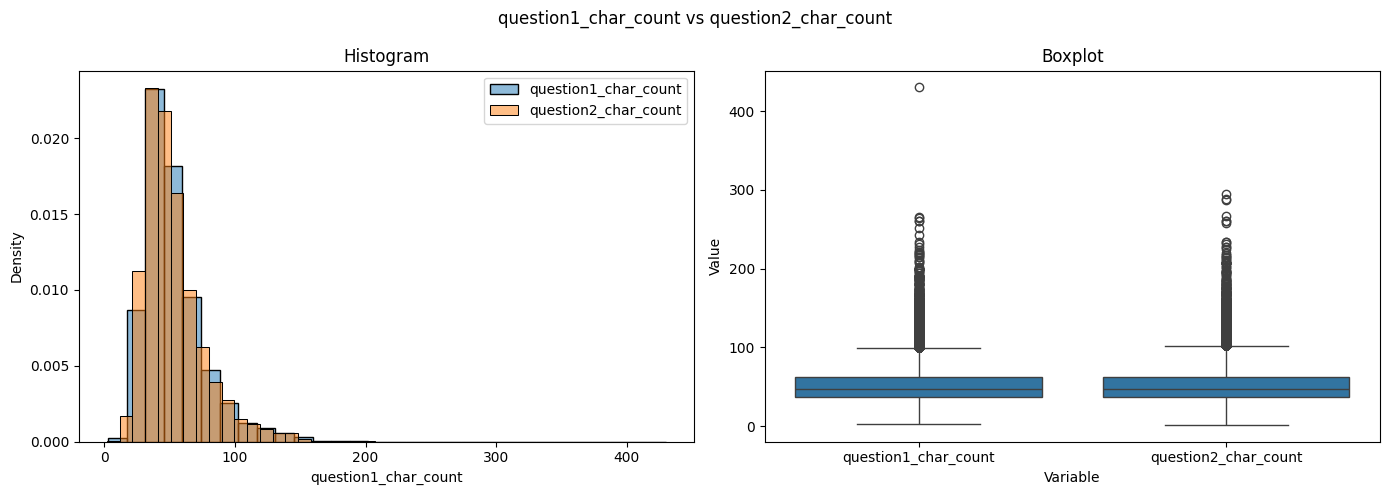

Word count distribution in questions


,question1_word_count,question2_word_count
count,119410.00,119410.00
mean,4.72,4.72
std,2.22,2.21
min,0.00,0.00
50%,4.00,4.00
90%,8.00,8.00
99%,12.00,12.00
max,43.00,29.00


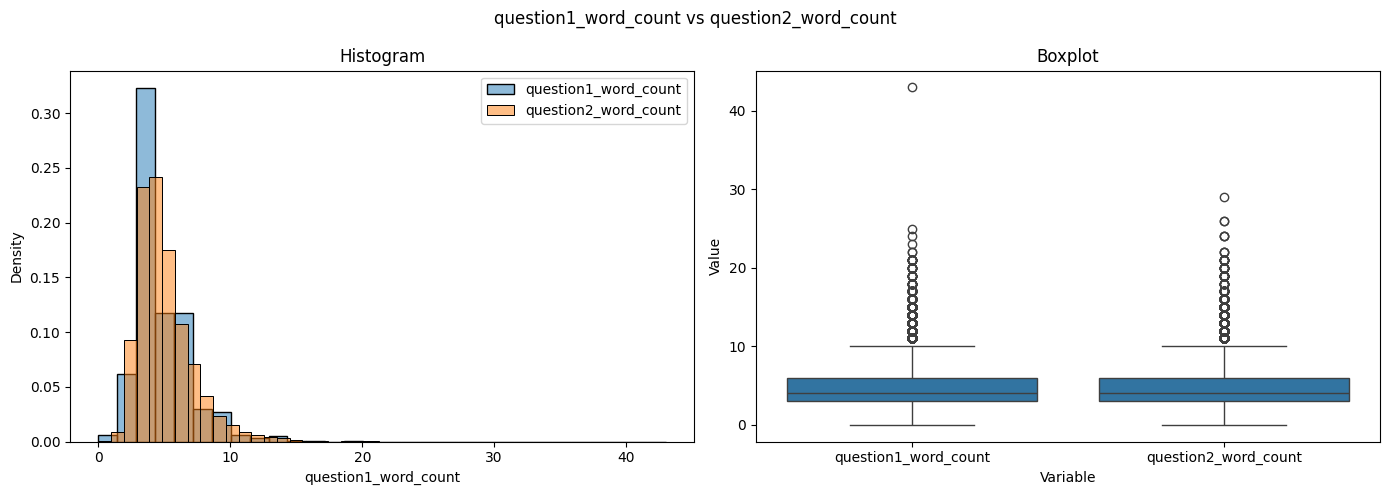

Distribution of the number of unique words in questions


,question1_unique_word_count,question2_unique_word_count
count,119410.00,119410.00
mean,4.62,4.62
std,2.08,2.08
min,0.00,0.00
50%,4.00,4.00
90%,7.00,7.00
99%,11.00,11.00
max,42.00,23.00


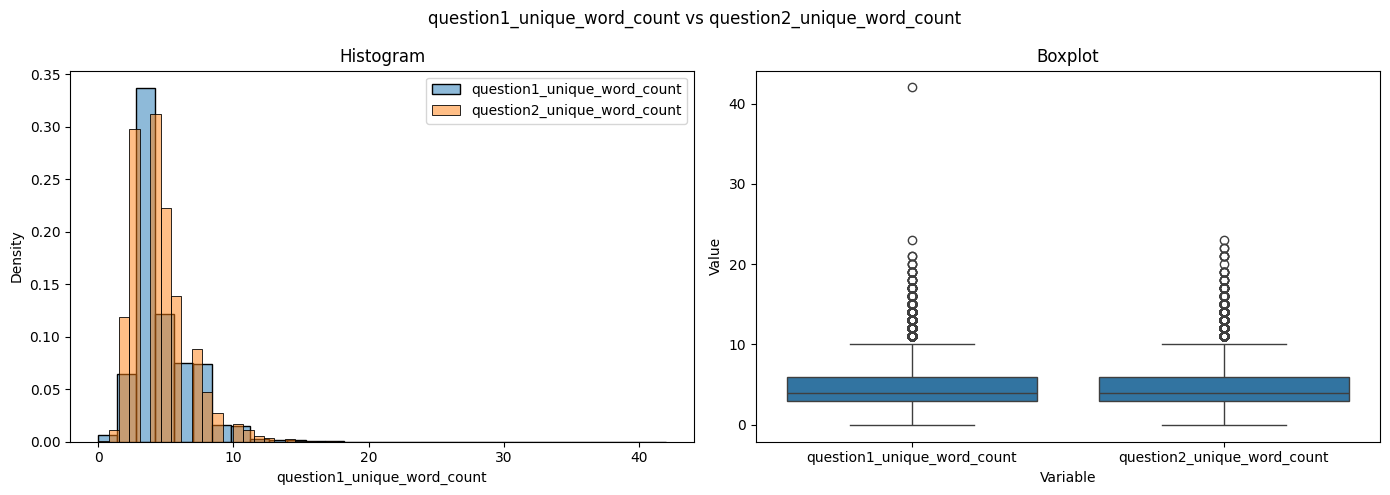

Distribution of average word lengths in questions


,question1_avg_word_length,question2_avg_word_length
count,119410.00,119410.00
mean,5.95,5.96
std,1.26,1.26
min,0.00,0.00
50%,5.80,5.83
90%,7.50,7.50
99%,9.50,9.60
max,17.00,17.00


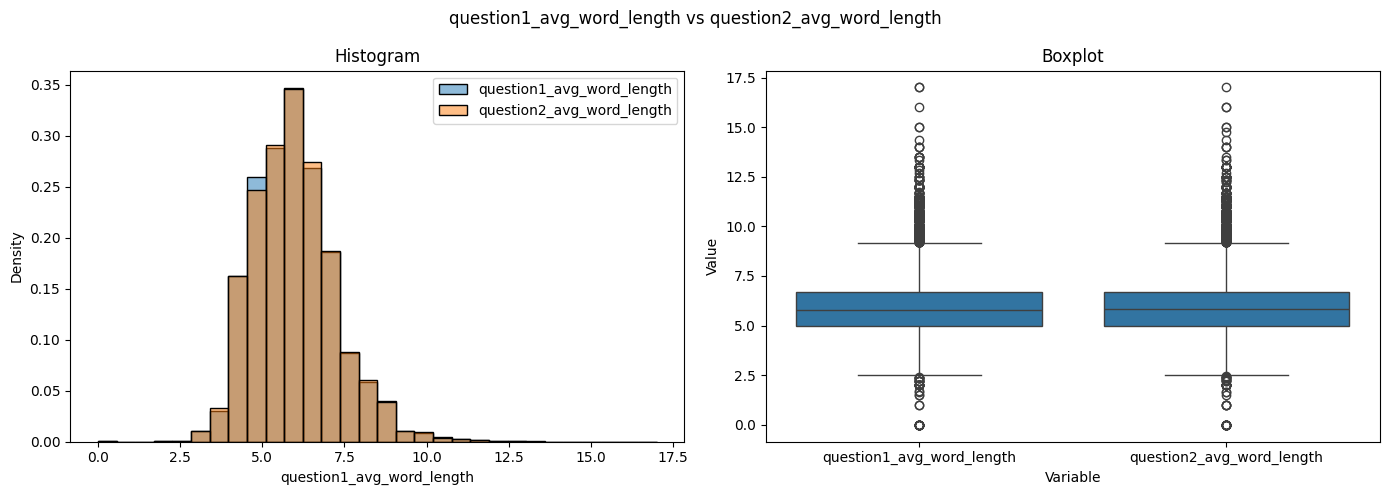

Distribution of maximum word length in questions


,question1_max_word_length,question2_max_word_length
count,119410.00,119410.00
mean,8.41,8.42
std,2.16,2.17
min,0.00,0.00
50%,8.00,8.00
90%,11.00,11.00
99%,14.00,14.00
max,52.00,52.00


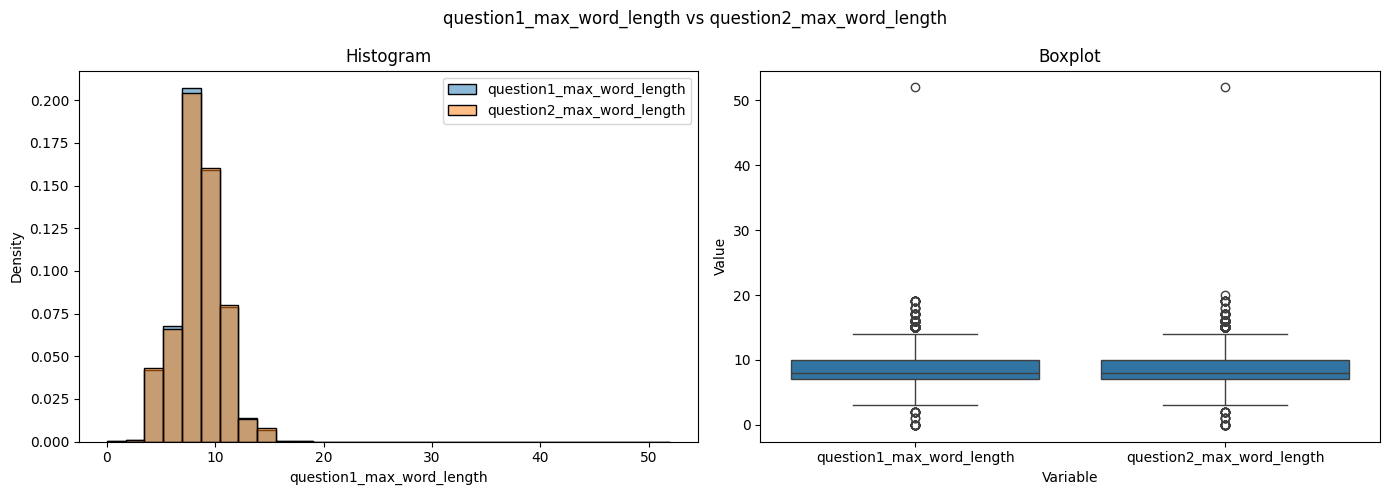

In [38]:
print("Question length distribution")
display(question_nosw_stats_df1[['question1_char_count', 'question2_char_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df1['question1_char_count'], question_nosw_stats_df1['question2_char_count'])

print("Word count distribution in questions")
display(question_nosw_stats_df1[['question1_word_count', 'question2_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df1['question1_word_count'], question_nosw_stats_df1['question2_word_count'])

print("Distribution of the number of unique words in questions")
display(question_nosw_stats_df1[['question1_unique_word_count', 'question2_unique_word_count']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df1['question1_unique_word_count'], question_nosw_stats_df1['question2_unique_word_count'])

print("Distribution of average word lengths in questions")
display(question_nosw_stats_df1[['question1_avg_word_length', 'question2_avg_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df1['question1_avg_word_length'], question_nosw_stats_df1['question2_avg_word_length'])

print("Distribution of maximum word length in questions")
display(question_nosw_stats_df1[['question1_max_word_length', 'question2_max_word_length']].describe(percentiles=[0.9, 0.99]).round(2))
distribution_plot(question_nosw_stats_df1['question1_max_word_length'], question_nosw_stats_df1['question2_max_word_length'])

**Observations:**
- Sentences that are found to be duplicates are significantly shorter compared to those that are not.
- Questions that are not duplicated have a higher proportion of unique words compared to those that are duplicated.

# Correlation of features and target

Correlation of is_duplicate with features:


common_ratio         0.3898
jaccard              0.3773
common_word_count    0.2402
len_diff_words      -0.2131
len_diff_chars      -0.2094
Name: is_duplicate, dtype: float64

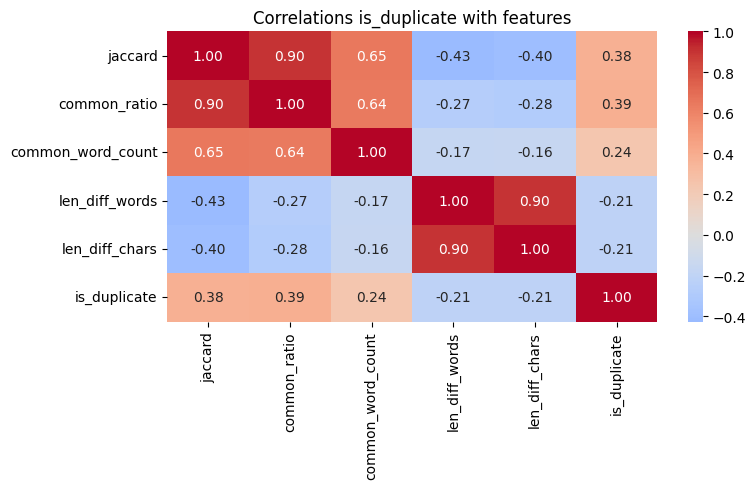

In [39]:
feature_cols = ["jaccard", "common_ratio", "common_word_count", "len_diff_words", "len_diff_chars"]

columns_to_check = feature_cols + ["is_duplicate"]
correlation_table = overlap_df[columns_to_check].corr()

correlation_with_target = correlation_table["is_duplicate"].drop("is_duplicate")

print("Correlation of is_duplicate with features:")
display(correlation_with_target.sort_values(key=abs, ascending=False).round(4))

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_table, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations is_duplicate with features")
plt.tight_layout()
plt.show()

**Observation:**
- According to the correlation matrix, as the proportion of identical words in questions increases, the probability that a pair of questions are duplicates increases.
- At the same time, as the number of different words or symbols in questions increases, the probability that the questions are duplicates decreases.

# EDA Conclusions

**Key points to consider when cleaning data**
1. There are 3 rows with missing questions (question1, qustion2), 3 rows will need to be deleted
2. There are 18 pairs with identical questions (question1, question2), 5 of which have the is_duplicate = 0 label, which accordingly marks them as unique questions; this situation may be a markup error, which should be taken into account and such cases should be deleted or the label should be replaced with 1 so that the model captures the correct patterns in the data

3. When forming the training and validation sample, it is necessary to take into account that the same question is assigned to the same data set, so that there is no data leakage.

4. There are typos and variant forms of adjectives, so it is worth considering stemming/lemmatization during preprocessing.

5. As additional features for training, you can use:
- common_ratio - the proportion of identical words in a pair of questions
- len_diff_words - the absolute difference in the number of words between questions, how much one question is longer than the other.

6. Class imbalance is present, but not critical, so at the current stage the use of class balancing methods is not expected.